In [25]:
import os

# Create all necessary directories at the start
directories = [
    '02-Declus_Z',
    '04-PPMT',
    '05-FDA',
    '05-Varcalc',
    '06-FPCA',
    '07-Varcalc',
    '09-Declus_Y',
    '10-NScore2',
    '11-USGSIM_Y_2d',
    '11-USGSIM_Y_2d_defoe',
    '12-NScore2_b_defoe',
    '13-FPCA_b',
    '14-USGSIM_Y_3d',
    '15-PPMT_b',
    '17-Validation',
    '18-FIGS',
    '19-etype',
    'figs_for_claude',
    '20-Correlograma',
]

for directory in directories:
    if not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)
        print(f'Created: {directory}')
    else:
        print(f'Exists: {directory}')


Exists: 02-Declus_Z
Exists: 04-PPMT
Exists: 05-FDA
Exists: 05-Varcalc
Exists: 06-FPCA
Exists: 07-Varcalc
Exists: 09-Declus_Y
Exists: 10-NScore2
Exists: 11-USGSIM_Y_2d
Exists: 11-USGSIM_Y_2d_defoe
Exists: 12-NScore2_b_defoe
Exists: 13-FPCA_b
Exists: 14-USGSIM_Y_3d
Exists: 15-PPMT_b
Exists: 17-Validation
Exists: 18-FIGS
Exists: 19-etype
Exists: figs_for_claude
Exists: 20-Correlograma


In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pygeostat as gs
import seaborn as sns
import missingno as msno

from scipy.interpolate import splrep, BSpline
from sklearn.preprocessing import SplineTransformer

from sklearn.decomposition import PCA

import skfda
from skfda.representation.interpolation import SplineInterpolation
from skfda.exploratory.visualization import FPCAPlot
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import (
    BSplineBasis,
    FourierBasis,
)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from memory_profiler import memory_usage


In [27]:
gs.PlotStyle['font.size'] = 16
color_perm = 'darkorange'
color_poro = 'olive'
poro='$\phi$'
perm='$\kappa$'
path = '18-FIGS/'


# Importing Dataset

In [28]:
data = gs.DataFile(flname='01-Data\Set1_wells.prn', x='X', y='Y', z='Z', tmin=-98) #tmin assign nan values
df = data.data


In [29]:
n_samples = len(df['Poro'])
k = round(1 + 3.322 * np.log(n_samples))
print(f'Número de amostras: {n_samples}')
print(f'Valor de k: {k}')


Número de amostras: 1335
Valor de k: 25


In [30]:
def sturges(df, column_name):
    n_samples = len(df[column_name])
    k = round(1 + 3.322 * np.log10(n_samples))
    return k


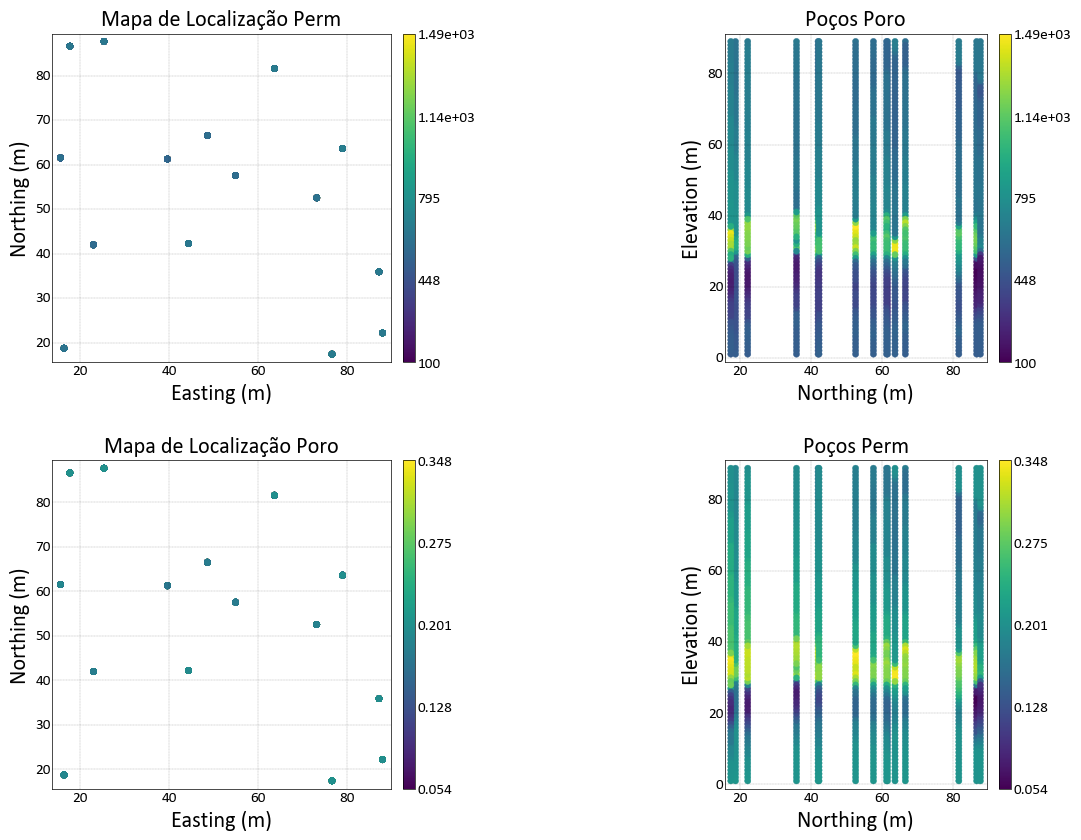

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

gs.location_plot(data=data, var='Perm', grid=True, title='Mapa de Localização Perm',  ax=axes[0,0])
gs.location_plot(data=data, var='Perm', orient='yz', grid=True, title='Poços Poro', ax=axes[0,1])


gs.location_plot(data=data, var='Poro', grid=True, title='Mapa de Localização Poro', ax=axes[1,0])
gs.location_plot(data=data, var='Poro', orient='yz', grid=True, title='Poços Perm', ax=axes[1,1])


# Aumentando o tamanho do título
for ax_row in axes:
    for ax in ax_row:
        ax.set_title(ax.get_title(), fontsize=16)

plt.subplots_adjust(wspace=0.2)
plt.subplots_adjust(hspace=0.3)
plt.show()


In [32]:
# group samples by 'x' and 'y' coordinates and assign them to a new column 'drillholes'

df['wells'] = df.groupby(['X', 'Y']).ngroup()

data.data.head(3)


,X,Y,Z,Poro,Ip,Perm,wells
0,17.692,86.628,1.0,0.205,7843.205,504.594,2
1,17.692,86.628,2.0,0.205,7843.208,504.594,2
2,17.692,86.628,3.0,0.205,7843.213,504.594,2


# Cell Declus

In [33]:
grid_3d = gs.GridDef('''101   0.0    1.0               -nx,xmn,xsiz
101   0.0    1.0               -ny,ymn,ysiz
90    0.0    1.0               -nz,zmn,zsiz ''')


In [34]:
data.spacing(n_nearest=4, x='X', y='Y', dh='wells')

lagdist_min = data['Data Spacing (m)'].values.min()
print('minimum data spacing in XY plane: {:.3f} {}'.format(lagdist_min,
                                                           gs.Parameters['plotting.unit']))

lagdist_max = data['Data Spacing (m)'].values.max()
print('maximum data spacing in XY plane: {:.3f} {}'.format(lagdist_max,
                                                           gs.Parameters['plotting.unit']))

lagdist_xy = data['Data Spacing (m)'].values.mean()
print('average data spacing in XY plane: {:.3f} {}'.format(lagdist_xy,
                                                           gs.Parameters['plotting.unit']))


minimum data spacing in XY plane: 16.066 m
maximum data spacing in XY plane: 37.994 m
average data spacing in XY plane: 23.298 m


In [35]:
declus=gs.Program('04-GSlib/declus.exe')

par_str = f'''                         Parameters for DECLUS_NN
                         ************************
START OF PARAMETERS:
{data}         -file with data
{data.gscol('X')}   {data.gscol('Y')}   {data.gscol('Z')}   {data.gscol('Poro')}               -  columns for X, Y, Z, and variable
-98.0     1.0e21          -  trimming limits
02-Declus_Z/declus_teste.sum                  -file for summary output
02-Declus_Z/declus_teste.out                  -file for output with data & weights
1.0   1.0                   -Y and Z cell anisotropy (Ysize=size*Yanis)
0                           -0=look for minimum declustered mean (1=max)
100  {lagdist_min}  {lagdist_max}               -number of cell sizes, min size, max size
5                           -number of origin offsets
'''

declus.run(parstr=par_str)


Calling:  ['04-GSlib/declus.exe', 'temp']

DECLUS Version: 2.906

 data file = 01-Data\Set1_wells.prn                  
 columns =           1           2           3           4
 tmin,tmax =      -98.000000    1.000000E+21
 summary file = 02-Declus_Z/declus_teste.sum            
 output file = 02-Declus_Z/declus_teste.out            
 anisotropy =        1.000000        1.000000
 minmax flag =           0
 ncell min max =         100       16.065540       37.993940
 offsets =           5


There are     1335 data with:
  mean value            =       .20147
  minimum and maximum   =       .05400      .34800
  size of data vol in X =     72.37000
  size of data vol in Y =     70.25700
  size of data vol in Z =     88.00000

  declustered mean      =       .19823
  min and max weight    =       .45552     3.30382
  equal weighting       =      1.00000


DECLUS Version: 2.906 Finished

Stop - Program terminated.



In [36]:
dataspacing_p90 = np.percentile(data['Data Spacing (m)'].values, 90)
dataspacing_p10 = np.percentile(data['Data Spacing (m)'].values, 10)
print(f'P90 data spacing: {dataspacing_p90}')
print(f'P90 data spacing: {dataspacing_p10}')


P90 data spacing: 27.395123011746
P90 data spacing: 16.84136405371437


### Run Declus

In [37]:
declus=gs.Program('04-GSlib/declus.exe')

par_str = f'''                         Parameters for DECLUS_NN
                         ************************
START OF PARAMETERS:
{data}         -file with data
{data.gscol('X')}   {data.gscol('Y')}   {data.gscol('Z')}   {data.gscol('Poro')}               -  columns for X, Y, Z, and variable
-98.0     1.0e21          -  trimming limits
02-Declus_Z/declus_poro.sum                  -file for summary output
02-Declus_Z/declus_poro.out                  -file for output with data & weights
1.0   1.0                   -Y and Z cell anisotropy (Ysize=size*Yanis)
0                           -0=look for minimum declustered mean (1=max)
1  {dataspacing_p90}  {dataspacing_p90}               -number of cell sizes, min size, max size
5                           -number of origin offsets
'''

declus.run(parstr=par_str)


Calling:  ['04-GSlib/declus.exe', 'temp']

DECLUS Version: 2.906

 data file = 01-Data\Set1_wells.prn                  
 columns =           1           2           3           4
 tmin,tmax =      -98.000000    1.000000E+21
 summary file = 02-Declus_Z/declus_poro.sum             
 output file = 02-Declus_Z/declus_poro.out             
 anisotropy =        1.000000        1.000000
 minmax flag =           0
 ncell min max =           1       27.395120       27.395120
 offsets =           5


There are     1335 data with:
  mean value            =       .20147
  minimum and maximum   =       .05400      .34800
  size of data vol in X =     72.37000
  size of data vol in Y =     70.25700
  size of data vol in Z =     88.00000

  declustered mean      =       .19974
  min and max weight    =       .48919     7.32409
  equal weighting       =      1.00000


DECLUS Version: 2.906 Finished

Stop - Program terminated.



In [ ]:
data_declus = gs.DataFile('02-Declus_Z/declus_poro.out', x='X', y= 'Y', z='Z')
data_declus.head()


,X,Y,Z,Poro,Ip,Perm,Declustering Weight
0,17.692,86.628,1.0,0.205,7843.205,504.594,1.581517
1,17.692,86.628,2.0,0.205,7843.208,504.594,1.581517
2,17.692,86.628,3.0,0.205,7843.213,504.594,1.581517
3,17.692,86.628,4.0,0.205,7843.148,504.596,1.581517
4,17.692,86.628,5.0,0.205,7843.716,504.574,1.581517


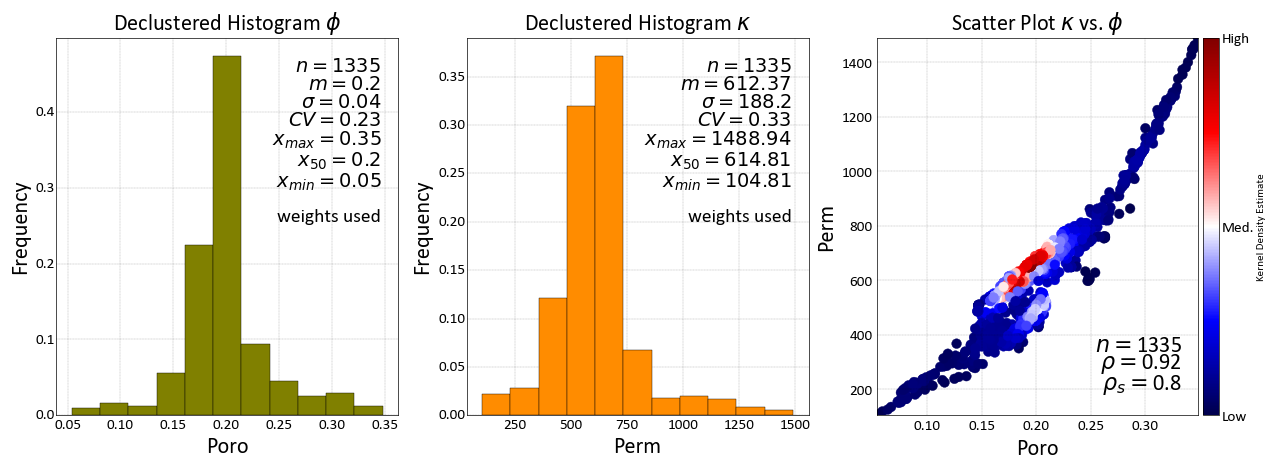

In [162]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

gs.histogram_plot(
    data=data_declus, var='Poro', grid=True, bins=sturges(data, 'Poro'),
    color=color_poro, stat_fontsize=14,
    title=f'Declustered Histogram {poro}',
    stat_blk=['count', 'mean', 'stdev', 'cvar', 'max', 'median', 'min'],
    ax=axes[0], weights='Declustering Weight'
)

gs.histogram_plot(
    data=data_declus, var='Perm', grid=True, bins=sturges(data, 'Poro'),
    color=color_perm, stat_fontsize=14,
    title=f'Declustered Histogram {perm}',
    stat_blk=['count', 'mean', 'stdev', 'cvar', 'max', 'median', 'min'],
    weights='Declustering Weight', ax=axes[1]
)

gs.scatter_plot(
    data['Poro'], data['Perm'], grid=True, cmap='seismic',
    title=f'Scatter Plot {perm} vs. {poro}',
    cbar=True, stat_blk='all', ax=axes[2]
)

plt.subplots_adjust(wspace=0.2)
plt.savefig(f'{path}hist_scatter.png')
plt.show()


# PPMT

In [40]:
ppmt = gs.Program('04-GSlib/ppmt.exe')


par_str = f'''                         Parameters for PPMT
                         *******************
START OF PARAMETERS:
{data_declus}             -input data file
2  {data_declus.gscol('Poro')} {data_declus.gscol('Perm')}  {data_declus.gscol('Declustering Weight')}              -  number of variables, variable cols, and wt col
-1.0e7      1.0e7             -  trimming limits
25 50 50             -min/max iterations and targeted Gauss perc. (see Note 1)
0                    -spatial decorrelation? (0=no,1=yes) (see Note 2)
{data_declus.gscol('X')} {data_declus.gscol('Y')} {data_declus.gscol('Z')}                -  x, y, z columns (0=none for z)
{lagdist_xy} {lagdist_xy/2}                -  lag distance, lag tolerance
04-PPMT/ppmt_nscore_w.out           -output data file with normal score transformed variables
04-PPMT/ppmt_w.out             -output data file with PPMT transformed variables
04-PPMT/ppmt_w.trn             -output transformation table (binary)

Note 1: Optional stopping criteria, where the projection pursuit algorithm will terminate
after reaching the targetted Gaussian percentile. The input percentile range is 1 (very Gaussian)
to 99 (barely Gaussian); the percentiles are calculated using random Gaussian distributions.
The min/max iterations overrides the targetted Gaussian percentile.

Note 2: Option to apply min/max autocorrelation factors after the projection pursuit algorithm
to decorrelate the variables at the specified non-zero lag distance.
'''

ppmt.run(parstr=par_str)


Calling:  ['04-GSlib/ppmt.exe', 'temp']

 PPMT version: 3.201

 input data file = 02-Declus_Z/declus_poro.out
 number of variables =    2
 columns for variables and weight =     4    6    7
 not using weights for transform
 trimming limits =  -.10E+08 0.10E+08
 min/max iters. & targeted percentile =    25   50   50
 not performing spatial decorrelation
 output file with univariate Gaussian variables = 04-PPMT/ppmt_nscore_w.out
 output file with multivariate Gaussian variables = 04-PPMT/ppmt_w.out
 output file with transform info = 04-PPMT/ppmt_w.trn
 
 loading the data
 
 normal scoring the data
 
 sphereing the data
 
 performing projection pursuit iterations
 maximum projection index:0.349646
 maximum projection index:0.205233
 maximum projection index:0.163955
 maximum projection index:0.094860
 maximum projection index:0.028465
 maximum projection index:0.028959
 maximum projection index:0.022218
 maximum projection index:0.021696
 maximum projection index:0.010116
 maximum project

In [41]:
data_ppmt = gs.DataFile('04-PPMT/ppmt_w.out ', x='X', y='Y', z='Z')
data_ppmt.data.head(3)


,X,Y,Z,Poro,Ip,Perm,Declustering Weight,PPMT:Poro,PPMT:Perm
0,17.692,86.628,1.0,0.205,7843.205,504.594,1.581517,1.111347,-1.493256
1,17.692,86.628,2.0,0.205,7843.208,504.594,1.581517,0.791050,-1.325053
2,17.692,86.628,3.0,0.205,7843.213,504.594,1.581517,0.838120,-1.463495


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


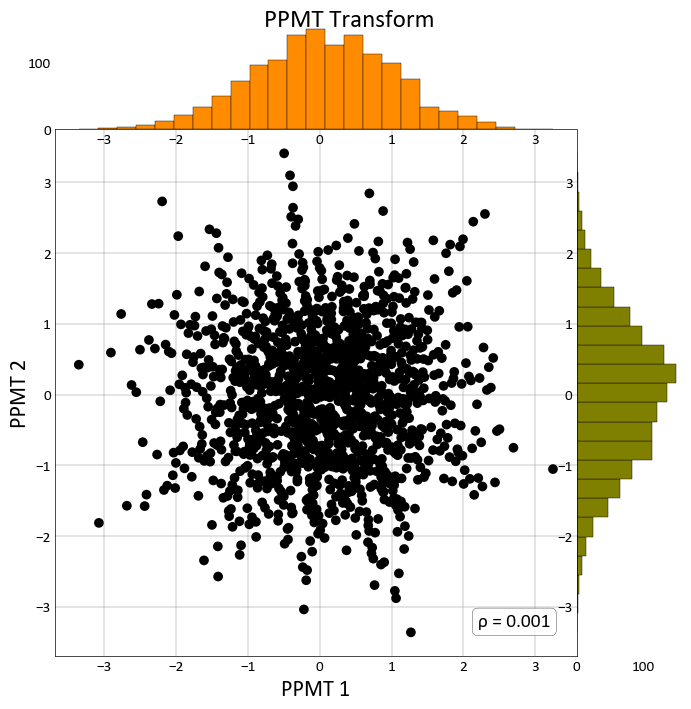

In [42]:
sturges(data_ppmt.data, "PPMT:Poro")

# Calcular coeficiente de correlação
corr = data_ppmt[['PPMT:Perm', 'PPMT:Poro']].corr().iloc[0, 1]

g = sns.jointplot(x="PPMT:Perm", y="PPMT:Poro", data=data_ppmt.data,
                  kind="scatter",
                  space=0,
                  color="black",
                  height=7,
                  joint_kws=dict(edgecolors='none')
                 )

g.fig.suptitle('PPMT Transform', fontsize=18, y=0.995)

g.ax_marg_x.clear()  
g.ax_marg_y.clear()  

g.ax_marg_x.hist(data_ppmt['PPMT:Perm'], color=color_perm, bins=k, edgecolor='black')
g.ax_marg_y.hist(data_ppmt['PPMT:Poro'], color=color_poro, orientation="horizontal", bins=k, edgecolor='black')

g.ax_joint.set_xlabel('PPMT 1', fontsize=16)
g.ax_joint.set_ylabel('PPMT 2', fontsize=16)
g.ax_joint.grid(True, linestyle='-', linewidth='0.3', color='gray')

# Adicionar coeficiente de correlação com rho
g.ax_joint.text(0.95, 0.05, f'ρ = {corr:.3f}', 
                transform=g.ax_joint.transAxes,
                fontsize=14, 
                ha='right', 
                va='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.savefig(f'{path}PPMT_transform.eps', format='eps', bbox_inches='tight')
plt.savefig(f'{path}PPMT_transform.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


# FDA in PPMT components
\begin{equation}
f(t) = \sum_{i=1}^{k} (a_i \phi_i(t))
\end{equation}
Where $f(t)$ is the polynolial fit results; $a_i$ is the coefficients of the basis function and $\phi_i(t)$ is the basis function

In [43]:
# group samples by 'x' and 'y' coordinates and assign them to a new column 'drillholes'

data_ppmt['wells'] = data_ppmt.data.groupby(['X', 'Y']).ngroup()

data_ppmt.data


,X,Y,Z,Poro,Ip,Perm,Declustering Weight,PPMT:Poro,PPMT:Perm,wells
0,17.692,86.628,1.0,0.205,7843.205,504.594,1.581517,1.111347,-1.493256,2
1,17.692,86.628,2.0,0.205,7843.208,504.594,1.581517,0.791050,-1.325053,2
2,17.692,86.628,3.0,0.205,7843.213,504.594,1.581517,0.838120,-1.463495,2
3,17.692,86.628,4.0,0.205,7843.148,504.596,1.581517,0.735782,-1.347433,2
4,17.692,86.628,5.0,0.205,7843.716,504.574,1.581517,0.715150,-1.166268,2
...,...,...,...,...,...,...,...,...,...,...
1330,48.595,66.555,85.0,0.158,6356.512,523.571,1.282146,-1.966225,-0.022784,7
1331,48.595,66.555,86.0,0.158,6354.327,525.433,1.282146,-1.915599,0.007509,7
1332,48.595,66.555,87.0,0.158,6354.719,525.124,1.282146,-1.823083,0.040965,7
1333,48.595,66.555,88.0,0.161,6351.974,536.537,1.282146,-1.983140,0.509015,7


In [44]:
wells_data = {f'data_w{i}': data_ppmt[data_ppmt['wells'] == i] for i in range(15)}



\begin{equation}
K = k + l - 2
\end{equation}
(for Third Order); Where K = number of samples in the original Ip logs, L is the order of the splines

In [ ]:
n_basis = 89
order = 2
n_wells = 15  


## Ploting FDA coefficients

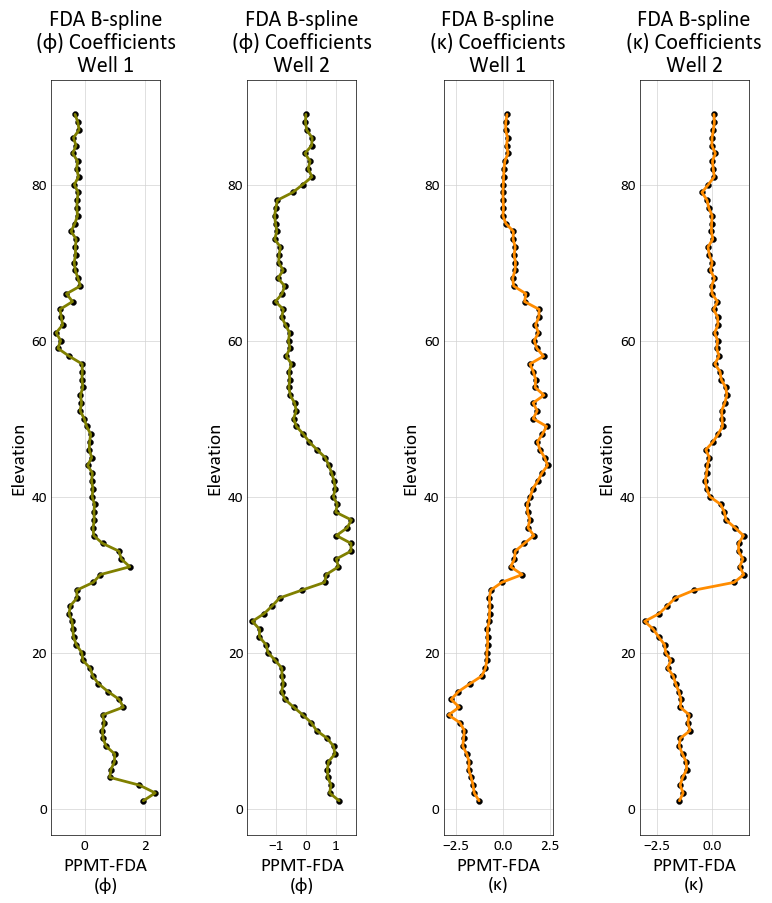

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(9, 10))

# Plot PORO data
for j, ax in enumerate(axes[:2]):  # Loop over the first 2 columns only
    well_index = j + 1  # Skipping the first well
    if well_index < n_wells:
        well_data = wells_data[f'data_w{well_index}']  # Access the 'data_w#' variable dynamically

        z_values = well_data['Z'].values
        grid_points = np.array(z_values)
        data_matrix_poro = np.array(well_data['PPMT:Poro'].values)

        fd_poro = skfda.FDataGrid(data_matrix=data_matrix_poro, grid_points=grid_points)

        basis_poro = skfda.representation.basis.BSplineBasis(n_basis=n_basis, order=order)
        X_basis_poro = fd_poro.to_basis(basis_poro)

        ax.plot(X_basis_poro.coefficients.T, grid_points, color=color_poro, label='(φ) BSpline', linewidth=2)
        ax.scatter(data_matrix_poro, grid_points, color='black', label='PPMT (φ)', s=18)

        ax.set_xlabel('PPMT-FDA\n(φ)', fontsize=14)
        ax.set_ylabel('Elevation', fontsize=14)
        ax.set_title('FDA B-spline\n(φ) Coefficients\nWell {}'.format(well_index), fontsize=16)
        ax.grid(True)

# Plot PERM data
for j, ax in enumerate(axes[2:]):  # Loop over the last 2 columns only
    well_index = j + 1  # Skipping the first well
    if well_index < n_wells:
        well_data = wells_data[f'data_w{well_index}'] # Access the 'data_w#' variable dynamically

        z_values = well_data['Z'].values
        grid_points = np.array(z_values)
        data_matrix_perm = np.array(well_data['PPMT:Perm'].values)

        fd_perm = skfda.FDataGrid(data_matrix=data_matrix_perm, grid_points=grid_points)

        basis_perm = skfda.representation.basis.BSplineBasis(n_basis=n_basis, order=order)
        X_basis_perm = fd_perm.to_basis(basis_perm)

        ax.plot(X_basis_perm.coefficients.T, grid_points, color=color_perm, label='FDA (κ)', linewidth=2)
        ax.scatter(data_matrix_perm, grid_points, color='black', label='FDA (φ)', s=18)

        ax.set_xlabel('PPMT-FDA\n(κ)', fontsize=14)
        ax.set_ylabel('Elevation', fontsize=14)
        ax.set_title('FDA B-spline\n(κ) Coefficients\nWell {}'.format(well_index), fontsize=16)
        ax.grid(True)

plt.subplots_adjust(wspace=0.8)
plt.savefig(f'{path}FDA_bsplines')
plt.show()


findfont: Font family ['Calibri'] not found. Falling back to Helvetica.


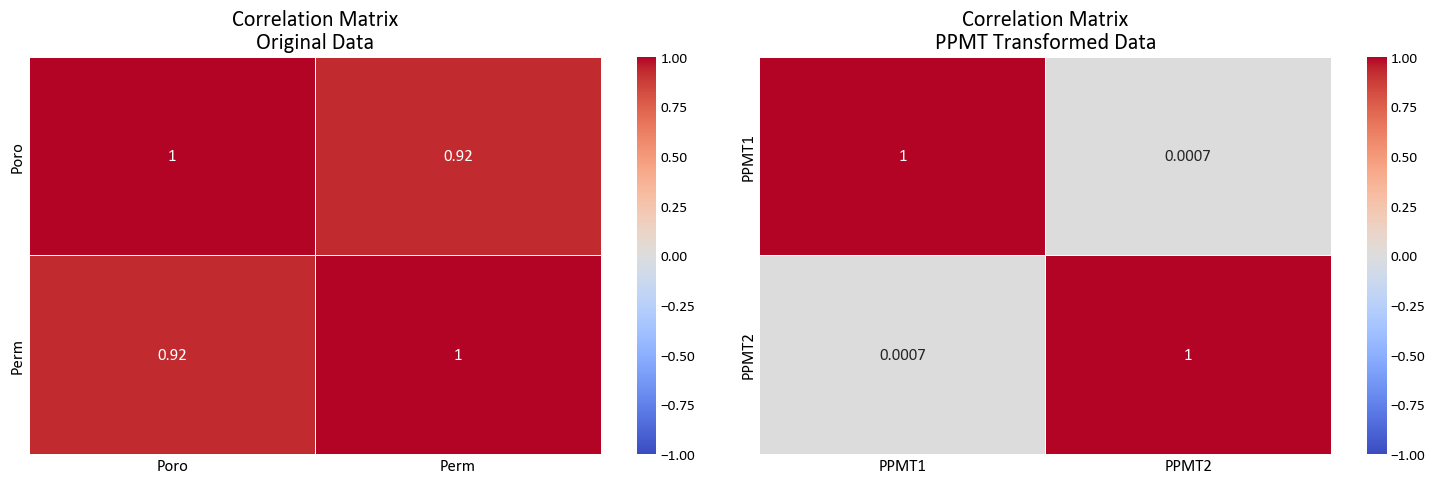

In [48]:
# Correlation matrix - Original vs PPMT transformed data
vars_org = ['Poro', 'Perm']
vars_ppmt = ['PPMT:Poro', 'PPMT:Perm']

# Rename mapping
rename_dict = {'PPMT:Poro': 'PPMT1', 'PPMT:Perm': 'PPMT2'}

vars_org_filtered_data = data_ppmt[vars_org]
vars_ppmt_filtered_data = data_ppmt[vars_ppmt].rename(columns=rename_dict)

vars_org_correlation_matrix = vars_org_filtered_data.corr()
vars_ppmt_correlation_matrix = vars_ppmt_filtered_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap for original data
sns.heatmap(vars_org_correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix\nOriginal Data', fontsize=16)
axes[0].tick_params(axis='x', labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)

# Heatmap for PPMT transformed data
sns.heatmap(vars_ppmt_correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix\nPPMT Transformed Data', fontsize=16)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

plt.tight_layout()
fig.savefig(f'{path}ppmt_descorrelation.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}ppmt_descorrelation.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


## Taking FDA coefficients

## PORO

In [ ]:
coefficients_poro = pd.DataFrame(columns=['well', 'X', 'Y', 'Z'] + ['Coef {}'.format(i) for i in range(1, 90)])


In [66]:
for i in range(15):
    well_data = data_ppmt[data_ppmt['wells'] == i]
    grid_points = np.array([well_data['Z'].values])
    data_matrix = np.array([well_data['PPMT:Poro'].values])
    fd = skfda.FDataGrid(data_matrix=data_matrix, grid_points=grid_points)
    basis = skfda.representation.basis.BSplineBasis(n_basis=n_basis, order=order) #K from the equation
    X_basis = fd.to_basis(basis)
    coefs = X_basis.coefficients[0]
    x = well_data['X'].iloc[0]
    y = well_data['Y'].iloc[0]
    z = well_data['Z'].iloc[0]
    row = {'well': i, 'X': x, 'Y': y, 'Z': z}
    row.update({'Coef {}'.format(j): coefs[j-1] for j in range(1, 90)}) 
    coefficients_poro = pd.concat([coefficients_poro, pd.DataFrame(row, index=[0])], ignore_index=True)


C:\Users\Bernardo.Silveira\AppData\Local\Temp\ipykernel_22564\1471476567.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  coefficients_poro = pd.concat([coefficients_poro, pd.DataFrame(row, index=[0])], ignore_index=True)


## PERM

In [67]:
coefficients_perm = pd.DataFrame(columns=['well', 'X', 'Y', 'Z'] + ['Coef {}'.format(i) for i in range(1, 90)])


In [68]:
for i in range(15):
    well_data = data_ppmt[data_ppmt['wells'] == i]
    grid_points = np.array([well_data['Z'].values])
    data_matrix = np.array([well_data['PPMT:Perm'].values])
    fd = skfda.FDataGrid(data_matrix=data_matrix, grid_points=grid_points)
    basis = skfda.representation.basis.BSplineBasis(n_basis=n_basis, order=order) #K from the equation
    X_basis = fd.to_basis(basis)
    coefs = X_basis.coefficients[0]
    x = well_data['X'].iloc[0]
    y = well_data['Y'].iloc[0]
    z = well_data['Z'].iloc[0]
    row = {'well': i, 'X': x, 'Y': y, 'Z': z}
    row.update({'Coef {}'.format(j): coefs[j-1] for j in range(1, 90)}) # 90 coefficients = n_basis
    coefficients_perm = pd.concat([coefficients_perm, pd.DataFrame(row, index=[0])], ignore_index=True)


C:\Users\Bernardo.Silveira\AppData\Local\Temp\ipykernel_22564\3089207563.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  coefficients_perm = pd.concat([coefficients_perm, pd.DataFrame(row, index=[0])], ignore_index=True)


# Transpose coefficients

In [69]:
coefficients_poro.to_csv('05-FDA/data_ppmt_fda_coefs_poro.dat')
coefficients_perm.to_csv('05-FDA/data_ppmt_fda_coefs_perm.dat')


# FPCA

In [70]:
coef = [f'Coef {i}' for i in range(1, 90)]


findfont: Font family ['Calibri'] not found. Falling back to Helvetica.


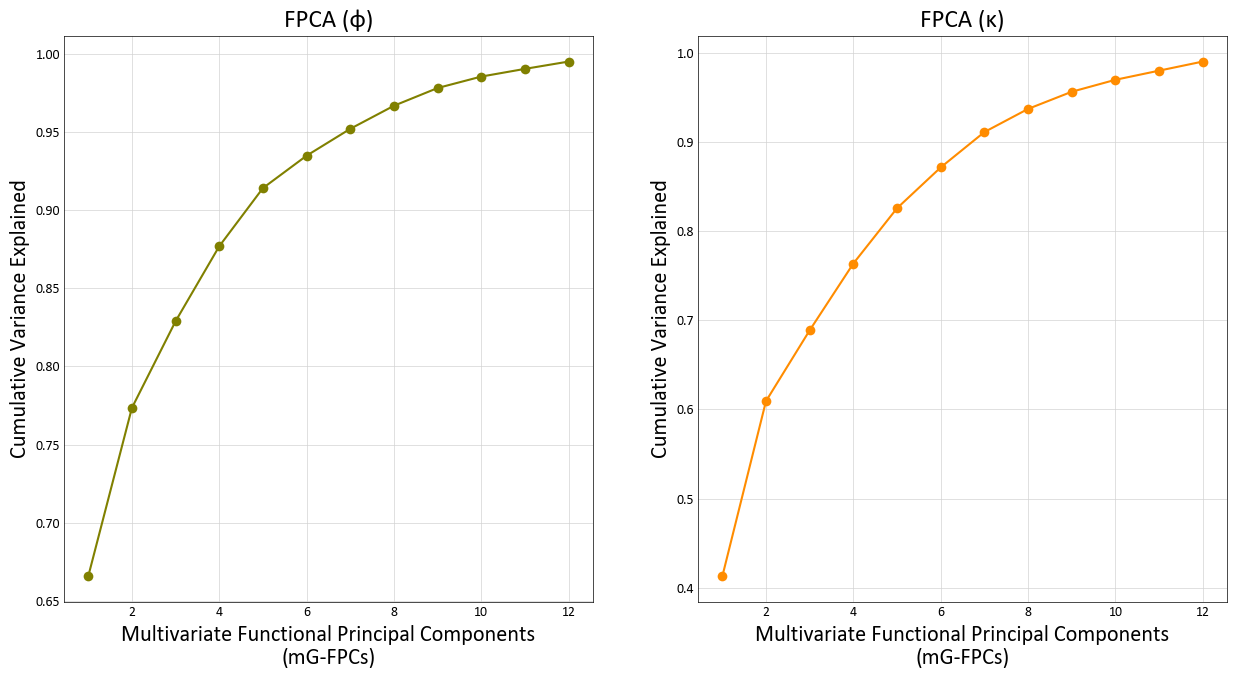

In [71]:
# PCA on FDA coefficients

pca_poro = PCA(n_components=12)
pca_perm = PCA(n_components=12)

# Fit PCA models
pca_poro.fit(coefficients_poro[coef].values)
pca_perm.fit(coefficients_perm[coef].values)

# Transform data to reduced dimensional space
X_poro_pca = pca_poro.transform(coefficients_poro[coef].values)
X_perm_pca = pca_perm.transform(coefficients_perm[coef].values)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))

# Cumulative explained variance - Porosity (φ)
axes[0].plot(np.arange(1, 13), pca_poro.explained_variance_ratio_.cumsum(), 'o-', color=color_poro)
axes[0].set_title('FPCA (φ)', fontsize=18)
axes[0].set_xlabel('Multivariate Functional Principal Components\n(mG-FPCs)', fontsize=16)
axes[0].set_ylabel('Cumulative Variance Explained', fontsize=16)
axes[0].tick_params(labelsize=10)
axes[0].grid(True)

# Cumulative explained variance - Permeability (κ)
axes[1].plot(np.arange(1, 13), pca_perm.explained_variance_ratio_.cumsum(), 'o-', color=color_perm)
axes[1].set_title('FPCA (κ)', fontsize=18)
axes[1].set_xlabel('Multivariate Functional Principal Components\n(mG-FPCs)', fontsize=16)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=16)
axes[1].tick_params(labelsize=10)
axes[1].grid(True)

plt.subplots_adjust(wspace=0.2)
fig.savefig(f'{path}FPCA_bsplines.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}FPCA_bsplines.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


## Creating PORO PCs DataFrame

In [72]:
# Create a new data frame with the transformed features and X, Y columns
df_poro_pca = pd.DataFrame(X_poro_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12'])
df_poro_pca['X'] = coefficients_poro['X']
df_poro_pca['Y'] = coefficients_poro['Y']
df_poro_pca['Z'] = 0  # Zero = origem

df_poro_pca = df_poro_pca.reindex(columns=['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12'])

df_poro_pca[['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12']] = df_poro_pca[['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12']].astype(float)

df_poro_pca = gs.DataFile(data=df_poro_pca.values, columns=df_poro_pca.columns)

gs.write_gslib(df_poro_pca, '06-FPCA/ppmt_poro_pca_gslib.dat')

ppmt_poro_pca = gs.DataFile('06-FPCA/ppmt_poro_pca_gslib.dat', x='X', y='Y', z='Z', tmin=-1.0e21)

ppmt_poro_pca.head(4)


,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,15.579,61.537,0.0,-1.760797,-0.056214,2.658517,0.513909,-0.844122,-1.256827,-1.912186,0.356993,0.217031,0.609259,0.093129,-0.310306
1,16.372,18.749,0.0,-0.883121,0.780030,-0.902054,-3.427588,1.950106,-1.697072,-0.011046,-0.643961,0.082891,-0.331861,-0.065374,-0.316479
2,17.692,86.628,0.0,-0.004501,3.361060,-0.582820,1.583066,-0.908772,-0.327229,0.131229,-0.422864,-0.753205,-1.165783,0.255168,-0.138568
3,22.975,41.992,0.0,0.521334,1.414758,1.166385,-1.298540,0.186838,0.028080,1.571637,1.561382,-0.078266,0.552087,0.661838,0.307360


## Creating PERM PCs DataFrame

In [73]:
# Create a new data frame with the transformed features and X, Y columns
df_perm_pca = pd.DataFrame(X_perm_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12'])
df_perm_pca['X'] = coefficients_perm['X']
df_perm_pca['Y'] = coefficients_perm['Y']
df_perm_pca['Z'] = 0  # Zero = origem

df_perm_pca = df_perm_pca.reindex(columns=['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12'])

df_perm_pca[['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12']] = df_perm_pca[['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12']].astype(float)

df_perm_pca = gs.DataFile(data=df_perm_pca.values, columns=df_perm_pca.columns)

gs.write_gslib(df_perm_pca, '06-FPCA/ppmt_perm_pca_gslib.dat')

ppmt_perm_pca = gs.DataFile('06-FPCA/ppmt_perm_pca_gslib.dat', x='X', y='Y', z='Z', tmin=-1.0e21)

ppmt_perm_pca.head(4)


,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,15.579,61.537,0.0,-2.037290,-2.816031,0.586629,-2.163039,0.137466,0.936337,-2.214024,1.033544,0.634613,-0.005061,-0.749112,0.593260
1,16.372,18.749,0.0,7.245091,-2.034488,0.041810,-1.504417,1.845318,0.864331,1.263006,0.400628,-1.218410,-0.528303,-0.294542,-0.514837
2,17.692,86.628,0.0,-2.285403,-3.473820,1.285614,1.280568,0.089249,-2.921014,0.374508,0.318992,-1.093881,0.719485,-0.385382,0.315659
3,22.975,41.992,0.0,6.143209,-1.249426,1.018325,-1.919681,-1.017644,-1.375874,-0.576106,-1.838715,0.959099,-0.004684,0.363757,0.079239


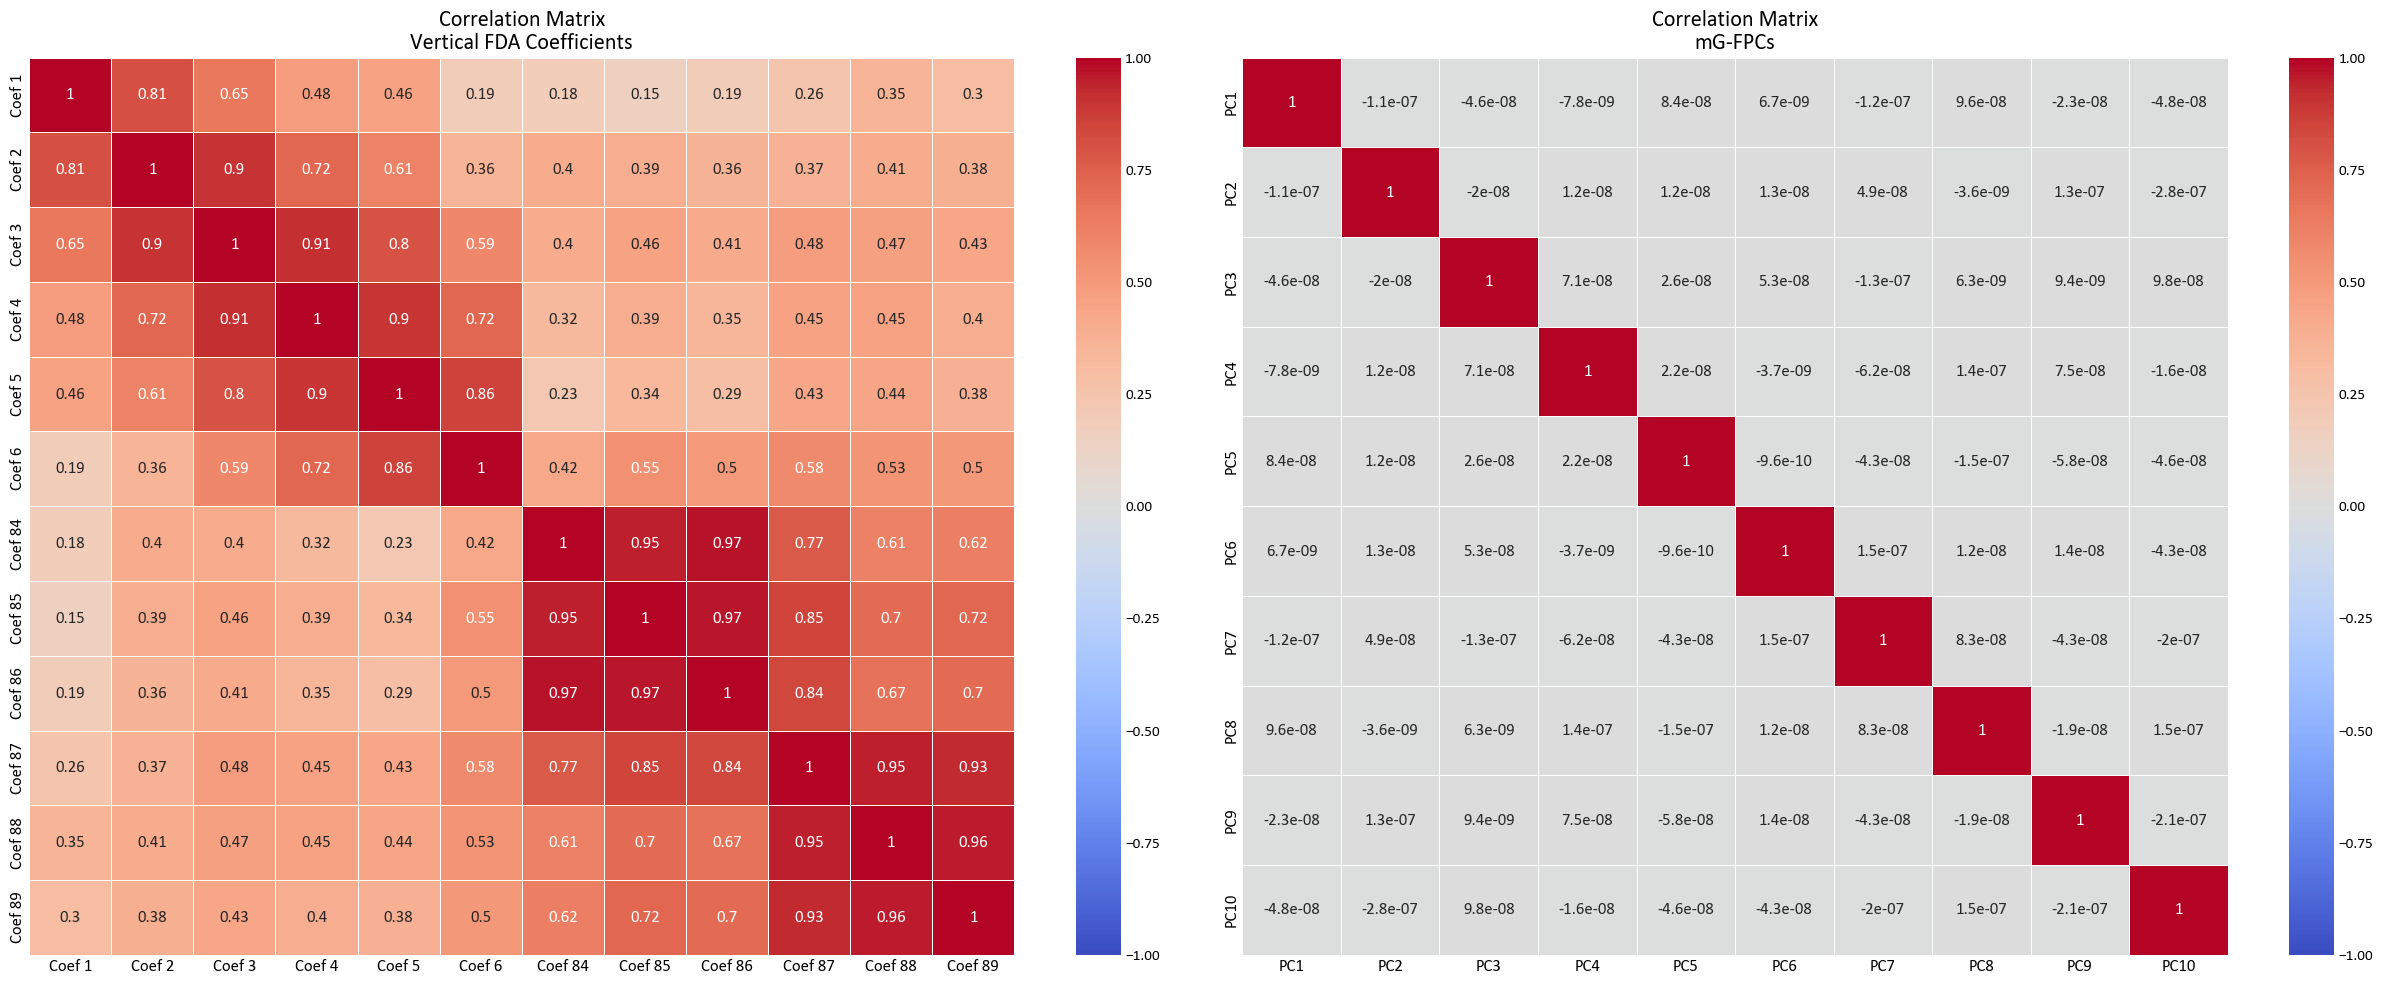

In [74]:
# Prepare coefficient data
coefs = [f'Coef {i}' for i in [*range(1, 7), *range(84, 90)]]
filtered_data = coefficients_perm[coefs]
correlation_matrix = filtered_data.corr()

# Prepare mFPC data (exclude spatial coordinates X, Y, Z)
pcs = [f'PC{i}' for i in range(1, 11)]
pc_filtered_data = ppmt_perm_pca.data[pcs]
descorrelation_matrix = pc_filtered_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(25, 10))

# Vertical FDA coefficients correlation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_title('Correlation Matrix\nVertical FDA Coefficients', fontsize=16)
axes[0].tick_params(axis='x', labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)

# mFPC correlation
sns.heatmap(descorrelation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[1], cbar=True)
axes[1].set_title('Correlation Matrix\nmG-FPCs', fontsize=16)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

plt.tight_layout()
fig.savefig(f'{path}geographic_descorrelation.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}geographic_descorrelation.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


# Variogram

## PORO

In [75]:
vars = [f'PC{i}' for i in range(1, 13)]


In [76]:
nscore = gs.Program('04-GSlib/nscoremv.exe')

concatenated_data = None  # Variable to store the concatenated data

for i, var in enumerate(vars, start=1):
    par_str = f'''                Parameters for NSCOREMV
                ************************

    START OF PARAMETERS:
    {ppmt_poro_pca}              -  file with data               
    1                           -  number of variables to transform
    {ppmt_poro_pca.gscol(var)}                 -  columns for variables      
    0                           -  columns for weights  
    -1.0e21 1.0e21                 -  trimming limits
    07-Varcalc/poro_nscore2_{var}.out                  -  file for output              
    07-Varcalc/poro_nscore2_{var}.trn                -  file for first transformation table
    0  0  0                     -  transform according to ref. dist., column numbers
    histsmth.out                -  file with reference dist.  
    0  0  0                     -  transform according to ref. dist., column numbers
    histsmth.out                -  file with reference dist.  
    '''
    nscore.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 06-FPCA/ppmt_poro_pca_gslib.dat         
  Number of variables to transform =            1
  columns for variables:  4 
  columns for weights:    0 
  file for output = 07-Varcalc/poro_nscore2_PC1.out         
  file for transformation table            1  = 
 07-Varcalc/poro_nscore2_PC1.trn         
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished

Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 06-FPCA/ppmt_poro_pca_gslib.dat         
  Number of variables to transform =            1
  columns for variables:  5 
  columns for weights:    0 
  file for output = 07-Varcalc/poro_nscore2_PC2.out         
  file for transformation table            1  = 
 07-Varcalc/poro_nscore2_PC2.trn         
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished



In [77]:
import glob

folder_path = '07-Varcalc'

# Get a list of all files in the folder with the pattern 'poro_nscore2_PC*.out'
file_paths = glob.glob(f'{folder_path}/poro_nscore2_PC*.out')

output_data_files = {}  # Dictionary to store the DataFile objects with variable names as keys

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'PC1', 'PC2', etc.)
    var = file_path.split('_')[-1].split('.')[0]

    # Create the DataFile object and add it to the dictionary with the variable name as the key
    output_data_files[var] = gs.DataFile(file_path, x='X', y='Y', z='Z', tmin=-1.0e21)

# Now you have a dictionary output_data_files containing DataFile objects for each variable's output file, with variable names as keys.
# You can access each object using output_data_files['PC1'], output_data_files['PC2'], ..., output_data_files['PC7'].

# Get the last columns from each DataFile object and set unique column names
last_columns = [output_data_files[var].data.iloc[:, -1].rename(f'NScore: {var}') for var in output_data_files]

# Concatenate the last columns into a single DataFrame
concatenated_data = pd.concat(last_columns, axis=1)

# Update ppmt_poro_pca.data with the concatenated data
ppmt_poro_pca_nscore2 = pd.concat([ppmt_poro_pca.data, concatenated_data], axis=1)


In [78]:
ppmt_poro_pca_nscore2.to_csv('07-Varcalc/poro_nscore2_vario.csv')
dfl_ppmt_poro_pca = gs.DataFile('07-Varcalc/poro_nscore2_vario.csv', x='X', y='Y', z='Z', tmin=-1.0e21)
gs.write_gslib(dfl_ppmt_poro_pca, '07-Varcalc/poro_nscore2_vario.out')


## PERM

In [79]:
nscore = gs.Program('04-GSlib/nscoremv.exe')

concatenated_data = None  # Variable to store the concatenated data

for i, var in enumerate(vars, start=1):
    par_str = f'''                Parameters for NSCOREMV
                ************************

    START OF PARAMETERS:
    {ppmt_perm_pca}              -  file with data               
    1                           -  number of variables to transform
    {ppmt_perm_pca.gscol(var)}                 -  columns for variables      
    0                           -  columns for weights  
    -1.0e21 1.0e21                 -  trimming limits
    07-Varcalc/perm_nscore2_{var}.out                  -  file for output              
    07-Varcalc/perm_nscore2_{var}.trn                -  file for first transformation table
    0  0  0                     -  transform according to ref. dist., column numbers
    histsmth.out                -  file with reference dist.  
    0  0  0                     -  transform according to ref. dist., column numbers
    histsmth.out                -  file with reference dist.  
    '''
    nscore.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 06-FPCA/ppmt_perm_pca_gslib.dat         
  Number of variables to transform =            1
  columns for variables:  4 
  columns for weights:    0 
  file for output = 07-Varcalc/perm_nscore2_PC1.out         
  file for transformation table            1  = 
 07-Varcalc/perm_nscore2_PC1.trn         
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished

Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 06-FPCA/ppmt_perm_pca_gslib.dat         
  Number of variables to transform =            1
  columns for variables:  5 
  columns for weights:    0 
  file for output = 07-Varcalc/perm_nscore2_PC2.out         
  file for transformation table            1  = 
 07-Varcalc/perm_nscore2_PC2.trn         
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished



In [80]:
folder_path = '07-Varcalc'

# Get a list of all files in the folder with the pattern 'poro_nscore2_PC*.out'
file_paths = glob.glob(f'{folder_path}/perm_nscore2_PC*.out')

output_data_files = {}  # Dictionary to store the DataFile objects with variable names as keys

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'PC1', 'PC2', etc.)
    var = file_path.split('_')[-1].split('.')[0]

    # Create the DataFile object and add it to the dictionary with the variable name as the key
    output_data_files[var] = gs.DataFile(file_path, x='X', y='Y', z='Z', tmin=-1.0e21)

# Now you have a dictionary output_data_files containing DataFile objects for each variable's output file, with variable names as keys.
# You can access each object using output_data_files['PC1'], output_data_files['PC2'], ..., output_data_files['PC7'].

# Get the last columns from each DataFile object and set unique column names
last_columns = [output_data_files[var].data.iloc[:, -1].rename(f'NScore: {var}') for var in output_data_files]

# Concatenate the last columns into a single DataFrame
concatenated_data = pd.concat(last_columns, axis=1)

# Update ppmt_poro_pca.data with the concatenated data
ppmt_perm_pca_nscore2 = pd.concat([ppmt_perm_pca.data, concatenated_data], axis=1)


In [81]:
# vars_nscore2 = ['NScore: PC1', 'NScore: PC2', 'NScore: PC3', 'NScore: PC4', 'NScore: PC5', 'NScore: PC6', 'NScore: PC7', 'NScore: PC8', 'NScore: PC9', 'NScore: PC10', 'NScore: PC11', 'NScore: PC12']

# fig, axes = plt.subplots(4, 3, figsize=(8, 8))
# for i, var in enumerate(vars_nscore2):
#     row = i // 4  # Calculate the row index based on the loop iteration
#     col = i % 4   # Calculate the column index based on the loop iteration
#     gs.histogram_plot(ppmt_perm_pca_nscore2, var=var, grid=True, ax=axes[col, row])
# plt.suptitle('FPCA NSCORE2 Poro Histograms without wheights', fontsize=16)
# plt.tight_layout()  # To prevent overlapping of subplots and improve visualization
# plt.show()


In [82]:
ppmt_perm_pca_nscore2.to_csv('07-Varcalc/perm_nscore2_vario.csv')
dfl_ppmt_perm_pca = gs.DataFile('07-Varcalc/perm_nscore2_vario.csv', x='X', y='Y', z='Z', tmin=-1.0e21)
gs.write_gslib(dfl_ppmt_perm_pca, '07-Varcalc/perm_nscore2_vario.out')


# Variograms PPMT's 

# Cell 2D Declus PCs

## PORO

In [83]:
declus=gs.Program('04-GSlib/declus.exe')

par_str = f'''                         Parameters for DECLUS_NN
                         ************************
START OF PARAMETERS:
{ppmt_poro_pca}         -file with data
{ppmt_poro_pca.gscol('X')}   {ppmt_poro_pca.gscol('Y')}   {ppmt_poro_pca.gscol('Z')}   {ppmt_poro_pca.gscol('PC1')}               -  columns for X, Y, Z, and variable
-1.0e21     1.0e21          -  trimming limits
09-Declus_Y/poro_declus_2d.sum                  -file for summary output
09-Declus_Y/poro_declus_2d.out                  -file for output with data & weights
1.0   1.0                   -Y and Z cell anisotropy (Ysize=size*Yanis)
0                           -0=look for minimum declustered mean (1=max)
1  {dataspacing_p90}  {dataspacing_p90}               -number of cell sizes, min size, max size
5                           -number of origin offsets
'''

declus.run(parstr=par_str)


Calling:  ['04-GSlib/declus.exe', 'temp']

DECLUS Version: 2.906

 data file = 06-FPCA/ppmt_poro_pca_gslib.dat         
 columns =           1           2           3           4
 tmin,tmax =   -1.000000E+21    1.000000E+21
 summary file = 09-Declus_Y/poro_declus_2d.sum          
 output file = 09-Declus_Y/poro_declus_2d.out          
 anisotropy =        1.000000        1.000000
 minmax flag =           0
 ncell min max =           1       27.395120       27.395120
 offsets =           5


There are       15 data with:
  mean value            =       .00000
  minimum and maximum   =    -10.55387    10.14912
  size of data vol in X =     72.37000
  size of data vol in Y =     70.25700
  size of data vol in Z =       .00000

  declustered mean      =       .02113
  min and max weight    =       .62646     1.46153
  equal weighting       =      1.00000


DECLUS Version: 2.906 Finished

Stop - Program terminated.



In [84]:
ppmt_poro_fpca_declus = gs.DataFile('09-Declus_Y/poro_declus_2d.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_poro_fpca_declus.data.head(3)


,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,Declustering Weight
0,15.579,61.537,0.0,-1.760797,-0.056214,2.658517,0.513909,-0.844122,-1.256827,-1.912186,0.356993,0.217031,0.609259,0.093129,-0.310306,1.047240
1,16.372,18.749,0.0,-0.883121,0.780030,-0.902054,-3.427588,1.950106,-1.697072,-0.011046,-0.643961,0.082891,-0.331861,-0.065374,-0.316479,1.461526
2,17.692,86.628,0.0,-0.004501,3.361060,-0.582820,1.583066,-0.908772,-0.327229,0.131229,-0.422864,-0.753205,-1.165783,0.255168,-0.138568,0.910877


## PERM

In [85]:
declus=gs.Program('04-GSlib/declus.exe')

par_str = f'''                         Parameters for DECLUS_NN
                         ************************
START OF PARAMETERS:
{ppmt_perm_pca}         -file with data
{ppmt_perm_pca.gscol('X')}   {ppmt_perm_pca.gscol('Y')}   {ppmt_perm_pca.gscol('Z')}   {ppmt_perm_pca.gscol('PC1')}               -  columns for X, Y, Z, and variable
-1.0e21     1.0e21          -  trimming limits
09-Declus_Y/perm_declus_2d.sum                  -file for summary output
09-Declus_Y/perm_declus_2d.out                  -file for output with data & weights
1.0   1.0                   -Y and Z cell anisotropy (Ysize=size*Yanis)
0                           -0=look for minimum declustered mean (1=max)
1  {dataspacing_p90}  {dataspacing_p90}               -number of cell sizes, min size, max size
5                           -number of origin offsets
'''

declus.run(parstr=par_str)


Calling:  ['04-GSlib/declus.exe', 'temp']

DECLUS Version: 2.906

 data file = 06-FPCA/ppmt_perm_pca_gslib.dat         
 columns =           1           2           3           4
 tmin,tmax =   -1.000000E+21    1.000000E+21
 summary file = 09-Declus_Y/perm_declus_2d.sum          
 output file = 09-Declus_Y/perm_declus_2d.out          
 anisotropy =        1.000000        1.000000
 minmax flag =           0
 ncell min max =           1       27.395120       27.395120
 offsets =           5


There are       15 data with:
  mean value            =       .00000
  minimum and maximum   =     -4.55932     7.24509
  size of data vol in X =     72.37000
  size of data vol in Y =     70.25700
  size of data vol in Z =       .00000

  declustered mean      =       .13069
  min and max weight    =       .62646     1.46153
  equal weighting       =      1.00000


DECLUS Version: 2.906 Finished

Stop - Program terminated.



In [86]:
ppmt_perm_fpca_declus = gs.DataFile('09-Declus_Y/perm_declus_2d.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_perm_fpca_declus.data.head(3)


,X,Y,Z,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,Declustering Weight
0,15.579,61.537,0.0,-2.037290,-2.816031,0.586629,-2.163039,0.137466,0.936337,-2.214024,1.033544,0.634613,-0.005061,-0.749112,0.593260,1.047240
1,16.372,18.749,0.0,7.245091,-2.034488,0.041810,-1.504417,1.845318,0.864331,1.263006,0.400628,-1.218410,-0.528303,-0.294542,-0.514837,1.461526
2,17.692,86.628,0.0,-2.285403,-3.473820,1.285614,1.280568,0.089249,-2.921014,0.374508,0.318992,-1.093881,0.719485,-0.385382,0.315659,0.910877


# NScore with weights - USGSIM

## PORO

In [87]:
nscore = gs.Program('04-GSlib/nscoremv.exe')
par_str = f'''                Parameters for NSCOREMV
                ************************

START OF PARAMETERS:
{ppmt_poro_fpca_declus}              -  file with data               
6                           -  number of variables to transform
{ppmt_poro_fpca_declus.gscol('PC1')} {ppmt_poro_fpca_declus.gscol('PC2')} {ppmt_poro_fpca_declus.gscol('PC3')} {ppmt_poro_fpca_declus.gscol('PC4')} {ppmt_poro_fpca_declus.gscol('PC5')} {ppmt_poro_fpca_declus.gscol('PC6')}                  -  columns for variables      
16 16 16 16 16 16              -  columns for weights  
-1.0e21 1.0e21                 -  trimming limits
10-NScore2/poro_nscore2_1.out                  -  file for output              
10-NScore2/poro_nscore2_1_PC1.trn                -  file for first transformation table
10-NScore2/poro_nscore2_1_PC2.trn                -  file for second transformation table
10-NScore2/poro_nscore2_1_PC3.trn                -  file for first transformation table
10-NScore2/poro_nscore2_1_PC4.trn                -  file for second transformation table
10-NScore2/poro_nscore2_1_PC5.trn                -  file for first transformation table
10-NScore2/poro_nscore2_1_PC6.trn                -  file for second transformation table
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  


**Notes:

To transform according to a reference distribution, set the first number to the variable,
the second number to the column of the reference distribution variable, and the third column
to the weight if any.  If the variable column number is <= 0, this option will not be
considered so be sure to set it appropriately.

'''
nscore.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 09-Declus_Y/poro_declus_2d.out          
  Number of variables to transform =            6
  columns for variables:  4  5  6  7  8  9 
  columns for weights:   16 16 16 16 16 16 
  file for output = 10-NScore2/poro_nscore2_1.out           
  file for transformation table            1  = 
 10-NScore2/poro_nscore2_1_PC1.trn       
  file for transformation table            2  = 
 10-NScore2/poro_nscore2_1_PC2.trn       
  file for transformation table            3  = 
 10-NScore2/poro_nscore2_1_PC3.trn       
  file for transformation table            4  = 
 10-NScore2/poro_nscore2_1_PC4.trn       
  file for transformation table            5  = 
 10-NScore2/poro_nscore2_1_PC5.trn       
  file for transformation table            6  = 
 10-NScore2/poro_nscore2_1_PC6.trn       
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished



In [88]:
ppmt_poro_fpca_nscore2_1 = gs.DataFile('10-NScore2/poro_nscore2_1.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_poro_fpca_nscore2_1


DataFile: 10-NScore2/poro_nscore2_1.out
Attributes:
x: 'X',  y: 'Y',  z: 'Z',  weights: 'Declustering Weight',  
Variables:
'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'NScore: PC1', 'NScore: PC2', 'NScore: PC3', 'NScore: PC4', 'NScore: PC5', 'NScore: PC6'

In [89]:
nscore = gs.Program('04-GSlib/nscoremv.exe')
par_str = f'''                Parameters for NSCOREMV
                ************************

START OF PARAMETERS:
{ppmt_poro_fpca_nscore2_1}              -  file with data               
6                           -  number of variables to transform
{ppmt_poro_fpca_nscore2_1.gscol('PC7')} {ppmt_poro_fpca_nscore2_1.gscol('PC8')} {ppmt_poro_fpca_nscore2_1.gscol('PC9')} {ppmt_poro_fpca_nscore2_1.gscol('PC10')} {ppmt_poro_fpca_nscore2_1.gscol('PC11')} {ppmt_poro_fpca_nscore2_1.gscol('PC12')}                  -  columns for variables      
16 16 16 16 16 16              -  columns for weights  
-1.0e21 1.0e21                 -  trimming limits
10-NScore2/poro_nscore2_2.out                  -  file for output              
10-NScore2/poro_nscore2_2_PC7.trn                -  file for first transformation table
10-NScore2/poro_nscore2_2_PC8.trn                -  file for second transformation table
10-NScore2/poro_nscore2_2_PC9.trn                -  file for first transformation table
10-NScore2/poro_nscore2_2_PC10.trn                -  file for second transformation table
10-NScore2/poro_nscore2_2_PC11.trn                -  file for first transformation table
10-NScore2/poro_nscore2_2_PC12.trn                -  file for second transformation table
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  


**Notes:

To transform according to a reference distribution, set the first number to the variable,
the second number to the column of the reference distribution variable, and the third column
to the weight if any.  If the variable column number is <= 0, this option will not be
considered so be sure to set it appropriately.

'''
nscore.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 10-NScore2/poro_nscore2_1.out           
  Number of variables to transform =            6
  columns for variables: 10 11 12 13 14 15 
  columns for weights:   16 16 16 16 16 16 
  file for output = 10-NScore2/poro_nscore2_2.out           
  file for transformation table            1  = 
 10-NScore2/poro_nscore2_2_PC7.trn       
  file for transformation table            2  = 
 10-NScore2/poro_nscore2_2_PC8.trn       
  file for transformation table            3  = 
 10-NScore2/poro_nscore2_2_PC9.trn       
  file for transformation table            4  = 
 10-NScore2/poro_nscore2_2_PC10.trn      
  file for transformation table            5  = 
 10-NScore2/poro_nscore2_2_PC11.trn      
  file for transformation table            6  = 
 10-NScore2/poro_nscore2_2_PC12.trn      
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished



In [90]:
ppmt_poro_fpca_nscore2_2 = gs.DataFile('10-NScore2/poro_nscore2_2.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_poro_fpca_nscore2_2


DataFile: 10-NScore2/poro_nscore2_2.out
Attributes:
x: 'X',  y: 'Y',  z: 'Z',  weights: 'Declustering Weight',  
Variables:
'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'NScore: PC1', 'NScore: PC2', 'NScore: PC3', 'NScore: PC4', 'NScore: PC5', 'NScore: PC6', 'NScore: PC7', 'NScore: PC8', 'NScore: PC9', 'NScore: PC10', 'NScore: PC11', 'NScore: PC12'

## PERM

In [91]:
nscore = gs.Program('04-GSlib/nscoremv.exe')
par_str = f'''                Parameters for NSCOREMV
                ************************

START OF PARAMETERS:
{ppmt_perm_fpca_declus}              -  file with data               
6                           -  number of variables to transform
{ppmt_perm_fpca_declus.gscol('PC1')} {ppmt_perm_fpca_declus.gscol('PC2')} {ppmt_perm_fpca_declus.gscol('PC3')} {ppmt_perm_fpca_declus.gscol('PC4')} {ppmt_perm_fpca_declus.gscol('PC5')} {ppmt_perm_fpca_declus.gscol('PC6')}                 -  columns for variables      
16 16 16 16 1 16              -  columns for weights  
-1.0e21 1.0e21                 -  trimming limits
10-NScore2/perm_nscore2_1.out                  -  file for output              
10-NScore2/perm_nscore2_1_PC1.trn                -  file for first transformation table
10-NScore2/perm_nscore2_1_PC2.trn                -  file for second transformation table
10-NScore2/perm_nscore2_1_PC3.trn                -  file for first transformation table
10-NScore2/perm_nscore2_1_PC4.trn                -  file for second transformation table
10-NScore2/perm_nscore2_1_PC5.trn                -  file for first transformation table
10-NScore2/perm_nscore2_1_PC6.trn                -  file for second transformation table
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  


**Notes:

To transform according to a reference distribution, set the first number to the variable,
the second number to the column of the reference distribution variable, and the third column
to the weight if any.  If the variable column number is <= 0, this option will not be
considered so be sure to set it appropriately.

'''
nscore.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 09-Declus_Y/perm_declus_2d.out          
  Number of variables to transform =            6
  columns for variables:  4  5  6  7  8  9 
  columns for weights:   16 16 16 16  1 16 
  file for output = 10-NScore2/perm_nscore2_1.out           
  file for transformation table            1  = 
 10-NScore2/perm_nscore2_1_PC1.trn       
  file for transformation table            2  = 
 10-NScore2/perm_nscore2_1_PC2.trn       
  file for transformation table            3  = 
 10-NScore2/perm_nscore2_1_PC3.trn       
  file for transformation table            4  = 
 10-NScore2/perm_nscore2_1_PC4.trn       
  file for transformation table            5  = 
 10-NScore2/perm_nscore2_1_PC5.trn       
  file for transformation table            6  = 
 10-NScore2/perm_nscore2_1_PC6.trn       
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished



In [92]:
ppmt_perm_fpca_nscore2_1 = gs.DataFile('10-NScore2/perm_nscore2_1.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_perm_fpca_nscore2_1


DataFile: 10-NScore2/perm_nscore2_1.out
Attributes:
x: 'X',  y: 'Y',  z: 'Z',  weights: 'Declustering Weight',  
Variables:
'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'NScore: PC1', 'NScore: PC2', 'NScore: PC3', 'NScore: PC4', 'NScore: PC5', 'NScore: PC6'

In [93]:
nscore = gs.Program('04-GSlib/nscoremv.exe')
par_str = f'''                Parameters for NSCOREMV
                ************************

START OF PARAMETERS:
{ppmt_perm_fpca_nscore2_1}              -  file with data               
6                           -  number of variables to transform
{ppmt_perm_fpca_nscore2_1.gscol('PC7')} {ppmt_perm_fpca_nscore2_1.gscol('PC8')} {ppmt_perm_fpca_nscore2_1.gscol('PC9')} {ppmt_perm_fpca_nscore2_1.gscol('PC10')} {ppmt_perm_fpca_nscore2_1.gscol('PC11')} {ppmt_perm_fpca_nscore2_1.gscol('PC12')}                 -  columns for variables      
16 16 16 16 1 16              -  columns for weights  
-1.0e21 1.0e21                 -  trimming limits
10-NScore2/perm_nscore2_2.out                  -  file for output              
10-NScore2/perm_nscore2_2_PC7.trn                -  file for first transformation table
10-NScore2/perm_nscore2_2_PC8.trn                -  file for second transformation table
10-NScore2/perm_nscore2_2_PC9.trn                -  file for first transformation table
10-NScore2/perm_nscore2_2_PC10.trn                -  file for second transformation table
10-NScore2/perm_nscore2_2_PC11.trn                -  file for first transformation table
10-NScore2/perm_nscore2_2_PC12.trn                -  file for second transformation table
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  
0  0  0                     -  transform according to ref. dist., column numbers
histsmth.out                -  file with reference dist.  


**Notes:

To transform according to a reference distribution, set the first number to the variable,
the second number to the column of the reference distribution variable, and the third column
to the weight if any.  If the variable column number is <= 0, this option will not be
considered so be sure to set it appropriately.

'''
nscore.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv.exe', 'temp']

 NSCOREMV Version: 4.000

  data file = 10-NScore2/perm_nscore2_1.out           
  Number of variables to transform =            6
  columns for variables: 10 11 12 13 14 15 
  columns for weights:   16 16 16 16  1 16 
  file for output = 10-NScore2/perm_nscore2_2.out           
  file for transformation table            1  = 
 10-NScore2/perm_nscore2_2_PC7.trn       
  file for transformation table            2  = 
 10-NScore2/perm_nscore2_2_PC8.trn       
  file for transformation table            3  = 
 10-NScore2/perm_nscore2_2_PC9.trn       
  file for transformation table            4  = 
 10-NScore2/perm_nscore2_2_PC10.trn      
  file for transformation table            5  = 
 10-NScore2/perm_nscore2_2_PC11.trn      
  file for transformation table            6  = 
 10-NScore2/perm_nscore2_2_PC12.trn      
  Checking for reference distributions:
    not considering ref distributions

 NSCOREMV Version: 4.000 Finished



In [94]:
ppmt_perm_fpca_nscore2_2 = gs.DataFile('10-NScore2/perm_nscore2_2.out', x='X', y='Y', z='Z', tmin=-1.0e21)
ppmt_perm_fpca_nscore2_2.columns


Index(['X', 'Y', 'Z', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8',
       'PC9', 'PC10', 'PC11', 'PC12', 'Declustering Weight', 'NScore: PC1',
       'NScore: PC2', 'NScore: PC3', 'NScore: PC4', 'NScore: PC5',
       'NScore: PC6', 'NScore: PC7', 'NScore: PC8', 'NScore: PC9',
       'NScore: PC10', 'NScore: PC11', 'NScore: PC12'],
      dtype='object')

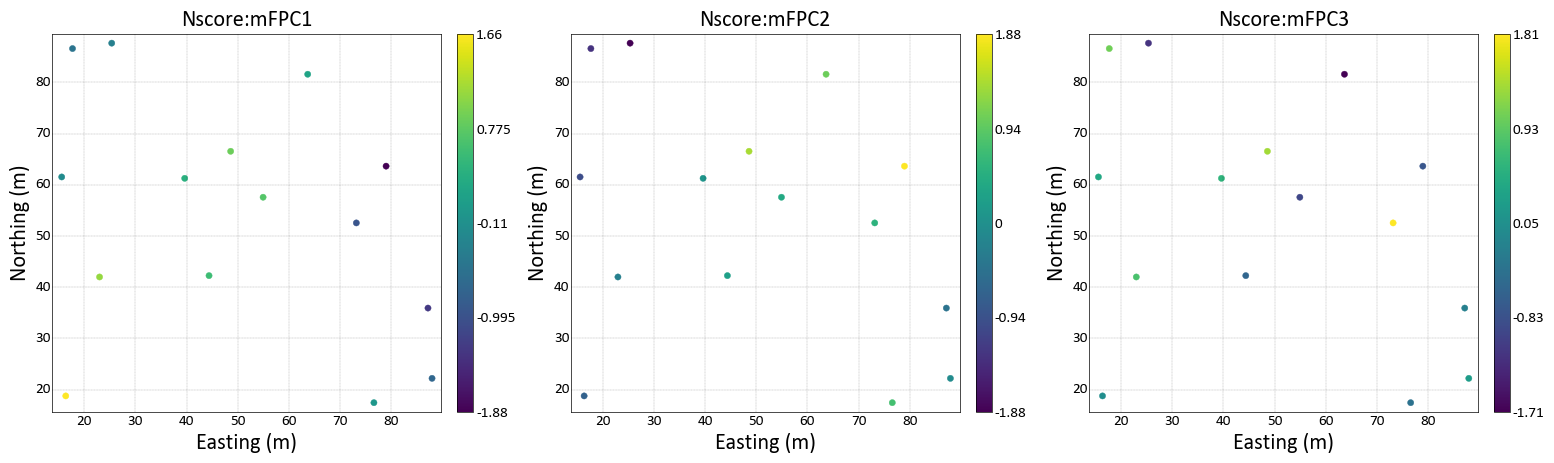

In [ ]:
vars_nscore = []
for i in range(1, 13):
    vars_nscore.append(f'NScore: PC{i}')

title = []
for i in range(1, 13):
    title.append(f'Nscore:mFPC{i}')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i in range(3):
    var = vars_nscore[i]
    gs.location_plot(ppmt_perm_fpca_nscore2_2, var=var, grid=True, ax=axes[i], title=title[i])

plt.subplots_adjust(hspace=0.4, wspace=0.01)
fig.savefig(f'{path}mFPC_location_plot.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}mFPC_location_plot.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


# USGSIM

In [101]:
grid_2d = gs.GridDef('''101   0.0    1.0               -nx,xmn,xsiz
101   0.0    1.0               -ny,ymn,ysiz
1    0.0    1.0               -nz,zmn,zsiz ''')


## PORO

In [102]:
n_real = 2
hmax_poro_pc1 = 58.0
hmax_poro_pc2 = 30.0
hmax_poro_pc3 = 33.0
hmax_poro_pc4 = 45.0
hmax_poro_pc5 = 50.0
hmax_poro_pc6 = 20.0
hmax_poro_pc7 = 18.0
hmax_poro_pc8 = 16.0
hmax_poro_pc9 = 27.0
hmax_poro_pc10 = 30.0
hmax_poro_pc11 = 28.0
hmax_poro_pc12 = 25.0


In [103]:
usgsim = gs.Program('04-GSlib/usgsim.exe')


In [104]:
def simulate_usgsim_poro():
    seed = 69069

    par_string = f'''Parameters for USGSIM
    *********************
START OF MAIN:
{n_real}                      -number of realizations to generate, 0=kriging
12                             -number of variables being simulated
0                             -number of rock types to consider
{seed}                           -random number seed
{grid_2d}
11-USGSIM_Y_2d/def_sgsimY_PCs_poro.out                     -file for simulation output
0                             -  output format: (0=reg, 1=coord, 2=binary)
11-USGSIM_Y_2d/def_impute_sgsimY_PCs_poro_real_def.out                    -file for imputed values in case of heterotopic samples
0                             -debugging level: 0,1,2,3
11-USGSIM_Y_2d/def_sgsimY_PCs_poro_real_def.dbg                     -file for debugging output

START OF SRCH:
40                            -number of data to use per variable
{hmax_poro_pc1}   {hmax_poro_pc1}   1.0            -maximum search radii (hmax,hmin,vert)
0.0    0.0    0.0             -angles for search ellipsoid
0                             -sort by distance (0) or covariance (1)
1 1 1                         -if sorting by covariance, indicate variogram rock type, head, tail to use

START OF VARG:
12                             -number of variograms
0  1  1                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc1}  {hmax_poro_pc1}  1.0     -  a_hmax, a_hmin, a_vert
0  2  2                       -rock type, variable 1, variable 2
1    0.1                      -  number of structures, nugget effect
1    0.9 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc2}  {hmax_poro_pc2}  1.0     -  a_hmax, a_hmin, a_vert
0  3  3                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc3}  {hmax_poro_pc3}  1.0     -  a_hmax, a_hmin, a_vert
0  4  4                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc4}  {hmax_poro_pc4}  1.0     -  a_hmax, a_hmin, a_vert
0  5  5                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc5}  {hmax_poro_pc5}  1.0     -  a_hmax, a_hmin, a_vert
0  6  6                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc6}  {hmax_poro_pc6}  1.0     -  a_hmax, a_hmin, a_vert
0  7  7                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc7}  {hmax_poro_pc7}  1.0     -  a_hmax, a_hmin, a_vert
0  8  8                       -rock type, variable 1, variable 2
1    0.1                      -  number of structures, nugget effect
1    0.9 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc8}  {hmax_poro_pc8}  1.0     -  a_hmax, a_hmin, a_vert
0  9  9                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc9}  {hmax_poro_pc9}  1.0     -  a_hmax, a_hmin, a_vert
0  10  10                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc10}  {hmax_poro_pc10}  1.0     -  a_hmax, a_hmin, a_vert
0  11  11                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc11}  {hmax_poro_pc11}  1.0     -  a_hmax, a_hmin, a_vert
0  12  12                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_poro_pc12}  {hmax_poro_pc12}  1.0     -  a_hmax, a_hmin, a_vert

START OF DATA:
{ppmt_poro_fpca_nscore2_2}                   -file with primary data
{ppmt_poro_fpca_nscore2_2.gscol('X')}  {ppmt_poro_fpca_nscore2_2.gscol('Y')} 0 {ppmt_poro_fpca_nscore2_2.gscol('Declustering Weight')}  0                 -  columns for X,Y,Z,wt,rock type
{ppmt_poro_fpca_nscore2_2.gscol('NScore: PC1')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC2')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC3')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC4')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC5')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC6')} {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC7')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC8')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC9')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC10')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC11')}  {ppmt_poro_fpca_nscore2_2.gscol('NScore: PC12')}     -  columns for variables
1                             -  clip data to grid, 1=yes
1                             -  assign to the grid, 0=none, 1=nearest, 2=average
-1.0e21       1.0e21             -  trimming limits

START OF MULT:
1                             -1=independent, 2=collocated, 4=full cokriging, 5=intrinsic, 6=BU
0                             -option for primary variables if BU / for secondary if full cokriging
1                             -perform cosimulation for multiple primary variables, 1=yes
0                             -rock type for correlation matrix
1 0 0 0 0 0 0 0 0 0 0 0
0 1 0 0 0 0 0 0 0 0 0 0
0 0 1 0 0 0 0 0 0 0 0 0 
0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 0 1 0 0 0 0 0 0 0
0 0 0 0 0 1 0 0 0 0 0 0
0 0 0 0 0 0 1 0 0 0 0 0
0 0 0 0 0 0 0 1 0 0 0 0
0 0 0 0 0 0 0 0 1 0 0 0
0 0 0 0 0 0 0 0 0 1 0 0
0 0 0 0 0 0 0 0 0 0 1 0
0 0 0 0 0 0 0 0 0 0 0 1
'''

    usgsim.run(parstr=par_string, liveoutput=True)

# Medindo o uso de memória
mem_usage = memory_usage(simulate_usgsim_poro)
print(f'Maximum memory usage: {max(mem_usage)} MiB')


Calling:  ['04-GSlib/usgsim.exe', 'temp']

 USGSIM VERSION 3.2.0


 Reading parameters

Found keyword START OF MAIN

 Reading MAIN Parameters

 number of realizations =     2
 number of variables =       12
 number of rock types =       0
 random number seed =     69069
 X grid specification =    101   0.000       1.000    
 Y grid specification =    101   0.000       1.000    
 Z grid specification =      1   0.000       1.000    
 output file 11-USGSIM_Y_2d/def_sgsimY_PCs_poro.out
 output format =    0
 imputation file 11-USGSIM_Y_2d/def_impute_sgsimY_PCs_poro_real_def.out
 debug level =    0
 debugging file 11-USGSIM_Y_2d/def_sgsimY_PCs_poro_real_def.dbg

Found keyword START OF SRC

 Reading SRCH Parameters

 number of nodes to use =   40
 search radii  =    58.00       58.00       1.000    
 search angles =    0.000       0.000       0.000    
 search sorting method =  0
 variogram index for sorting =     1    1    1

Could not locate START OF ROCK

Found keyword START OF VARG

 Re

In [105]:
data_poro_simY_reals = gs.DataFile('11-USGSIM_Y_2d/def_sgsimY_PCs_poro.out', griddef=grid_2d)
data_poro_simY_reals


DataFile: 11-USGSIM_Y_2d/def_sgsimY_PCs_poro.out
No Special Attributes Found 
Variables:
'variable_001', 'variable_002', 'variable_003', 'variable_004', 'variable_005', 'variable_006', 'variable_007', 'variable_008', 'variable_009', 'variable_010', 'variable_011', 'variable_012'
Grid Definitions:
101 0.0 1.0 
101 0.0 1.0 
1 0.0 1.0

In [106]:
grid_size_2d = grid_2d.count()
print(grid_size_2d)
df_poro_simY_real_1 = data_poro_simY_reals.data.iloc[:grid_size_2d,:].copy()
print(data_poro_simY_reals.shape, df_poro_simY_real_1.shape)


10201
(20402, 12) (10201, 12)


In [107]:
real_poro_dfs = []

for i in range(n_real):
    start_index = i * grid_size_2d
    end_index = (i + 1) * grid_size_2d
    df_real_poro = data_poro_simY_reals.data.iloc[start_index:end_index, :].copy()
    real_poro_dfs.append(df_real_poro)
    print(f"Real {i+1}: {df_real_poro.shape}")

# Verifique se a soma dos tamanhos dos DataFrames é igual ao tamanho total dos dados
total_rows = sum(df.shape[0] for df in real_poro_dfs)
print(f"Total rows: {total_rows}")


Real 1: (10201, 12)
Real 2: (10201, 12)
Total rows: 20402


## PERM

In [108]:
n_real = 2
hmax_perm_pc1 = 55.0
hmax_perm_pc2 = 55.0
hmax_perm_pc3 = 10.0
hmax_perm_pc4 = 28.0
hmax_perm_pc5 = 10.0
hmax_perm_pc6 = 35.0
hmax_perm_pc7 = 17.0
hmax_perm_pc8 = 10.0
hmax_perm_pc9 = 25.0
hmax_perm_pc10 = 25.0
hmax_perm_pc11 = 10.0
hmax_perm_pc12 = 25.0


In [109]:
#%load_ext memory_profiler

# Medindo a memória usada pelo bloco de código
#%%memit


seed=69069


par_string = f'''               Parameters for USGSIM
               *********************
START OF MAIN:
{n_real}                      -number of realizations to generate, 0=kriging
12                             -number of variables being simulated
0                             -number of rock types to consider
{seed}                           -random number seed
{grid_2d}
11-USGSIM_Y_2d/def_sgsimY_PCs_perm.out                     -file for simulation output
0                             -  output format: (0=reg, 1=coord, 2=binary)
11-USGSIM_Y_2d/def_impute_sgsimY_PCs_perm_real_def.out                    -file for imputed values in case of heterotopic samples
0                             -debugging level: 0,1,2,3
11-USGSIM_Y_2d/def_sgsimY_PCs_perm_real_def.dbg                     -file for debugging output                     -file for debugging output 


START OF SRCH:
40                            -number of data to use per variable
{hmax_perm_pc1}   {hmax_perm_pc1}   1.0            -maximum search radii (hmax,hmin,vert)
0.0    0.0    0.0             -angles for search ellipsoid
0                             -sort by distance (0) or covariance (1)
1 1 1                         -if sorting by covariance, indicate variogram rock type, head, tail to use


START OF VARG:
12                             -number of variograms
0  1  1                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc1}  {hmax_perm_pc1}  1.0     -  a_hmax, a_hmin, a_vert
0  2  2                       -rock type, variable 1, variable 2
1    0.1                      -  number of structures, nugget effect
1    0.9 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc2}  {hmax_perm_pc2}  1.0     -  a_hmax, a_hmin, a_vert
0  3  3                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc3}  {hmax_perm_pc3}  1.0     -  a_hmax, a_hmin, a_vert
0  4  4                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc4}  {hmax_perm_pc4}  1.0     -  a_hmax, a_hmin, a_vert
0  5  5                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc5}  {hmax_perm_pc5}  1.0     -  a_hmax, a_hmin, a_vert
0  6  6                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc6}  {hmax_perm_pc6}  1.0     -  a_hmax, a_hmin, a_vert
0  7  7                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc7}  {hmax_perm_pc7}  1.0     -  a_hmax, a_hmin, a_vert
0  8  8                       -rock type, variable 1, variable 2
1    0.1                      -  number of structures, nugget effect
1    0.9 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc8}  {hmax_perm_pc8}  1.0     -  a_hmax, a_hmin, a_vert
0  9  9                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc9}  {hmax_perm_pc9}  1.0     -  a_hmax, a_hmin, a_vert
0  10  10                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc10}  {hmax_perm_pc10}  1.0     -  a_hmax, a_hmin, a_vert
0  11  11                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc11}  {hmax_perm_pc11}  1.0     -  a_hmax, a_hmin, a_vert
0  12  12                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc12}  {hmax_perm_pc12}  1.0     -  a_hmax, a_hmin, a_vert

START OF DATA:
{ppmt_perm_fpca_nscore2_2}                   -file with primary data
{ppmt_perm_fpca_nscore2_2.gscol('X')}  {ppmt_perm_fpca_nscore2_2.gscol('Y')} 0 {ppmt_perm_fpca_nscore2_2.gscol('Declustering Weight')}  0                 -  columns for X,Y,Z,wt,rock type
{ppmt_perm_fpca_nscore2_2.gscol('NScore: PC1')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC2')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC3')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC4')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC5')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC6')} {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC7')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC8')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC9')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC10')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC11')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC12')}     -  columns for variables
1                             -  clip data to grid, 1=yes
1                             -  assign to the grid, 0=none, 1=nearest, 2=average
-1.0e21       1.0e21             -  trimming limits

START OF MULT:
1                             -1=independent, 2=collocated, 4=full cokriging, 5=intrinsic, 6=BU
0                             -option for primary variables if BU / for secondary if full cokriging
1                             -perform cosimulation for multiple primary variables, 1=yes
0                             -rock type for correlation matrix
1 0 0 0 0 0 0 0 0 0 0 0
0 1 0 0 0 0 0 0 0 0 0 0
0 0 1 0 0 0 0 0 0 0 0 0 
0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 0 1 0 0 0 0 0 0 0
0 0 0 0 0 1 0 0 0 0 0 0
0 0 0 0 0 0 1 0 0 0 0 0
0 0 0 0 0 0 0 1 0 0 0 0
0 0 0 0 0 0 0 0 1 0 0 0
0 0 0 0 0 0 0 0 0 1 0 0
0 0 0 0 0 0 0 0 0 0 1 0
0 0 0 0 0 0 0 0 0 0 0 1
'''
usgsim.run(parstr=par_string, liveoutput=True)


Calling:  ['04-GSlib/usgsim.exe', 'temp']

 USGSIM VERSION 3.2.0


 Reading parameters

Found keyword START OF MAIN

 Reading MAIN Parameters

 number of realizations =     2
 number of variables =       12
 number of rock types =       0
 random number seed =     69069
 X grid specification =    101   0.000       1.000    
 Y grid specification =    101   0.000       1.000    
 Z grid specification =      1   0.000       1.000    
 output file 11-USGSIM_Y_2d/def_sgsimY_PCs_perm.out
 output format =    0
 imputation file 11-USGSIM_Y_2d/def_impute_sgsimY_PCs_perm_real_def.out
 debug level =    0
 debugging file 11-USGSIM_Y_2d/def_sgsimY_PCs_perm_real_def.dbg

Found keyword START OF SRC

 Reading SRCH Parameters

 number of nodes to use =   40
 search radii  =    55.00       55.00       1.000    
 search angles =    0.000       0.000       0.000    
 search sorting method =  0
 variogram index for sorting =     1    1    1

Could not locate START OF ROCK

Found keyword START OF VARG

 Re

In [110]:
from memory_profiler import memory_usage

# Certifique-se de definir ou importar usgsim antes de usá-lo.
# Exemplo:
# from some_module import usgsim

def simulate_usgsim():
    seed = 69069

    par_string = f'''Parameters for USGSIM
    *********************
START OF MAIN:
{n_real}                      -number of realizations to generate, 0=kriging
12                             -number of variables being simulated
0                             -number of rock types to consider
{seed}                           -random number seed
{grid_2d}
11-USGSIM_Y_2d/def_sgsimY_PCs_perm.out                     -file for simulation output
0                             -  output format: (0=reg, 1=coord, 2=binary)
11-USGSIM_Y_2d/def_impute_sgsimY_PCs_perm_real_def.out                    -file for imputed values in case of heterotopic samples
0                             -debugging level: 0,1,2,3
11-USGSIM_Y_2d/def_sgsimY_PCs_perm_real_def.dbg                     -file for debugging output

START OF SRCH:
40                            -number of data to use per variable
{hmax_perm_pc1}   {hmax_perm_pc1}   1.0            -maximum search radii (hmax,hmin,vert)
0.0    0.0    0.0             -angles for search ellipsoid
0                             -sort by distance (0) or covariance (1)
1 1 1                         -if sorting by covariance, indicate variogram rock type, head, tail to use

START OF VARG:
12                             -number of variograms
0  1  1                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc1}  {hmax_perm_pc1}  1.0     -  a_hmax, a_hmin, a_vert
0  2  2                       -rock type, variable 1, variable 2
1    0.1                      -  number of structures, nugget effect
1    0.9 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc2}  {hmax_perm_pc2}  1.0     -  a_hmax, a_hmin, a_vert
0  3  3                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc3}  {hmax_perm_pc3}  1.0     -  a_hmax, a_hmin, a_vert
0  4  4                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc4}  {hmax_perm_pc4}  1.0     -  a_hmax, a_hmin, a_vert
0  5  5                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc5}  {hmax_perm_pc5}  1.0     -  a_hmax, a_hmin, a_vert
0  6  6                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc6}  {hmax_perm_pc6}  1.0     -  a_hmax, a_hmin, a_vert
0  7  7                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc7}  {hmax_perm_pc7}  1.0     -  a_hmax, a_hmin, a_vert
0  8  8                       -rock type, variable 1, variable 2
1    0.1                      -  number of structures, nugget effect
1    0.9 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc8}  {hmax_perm_pc8}  1.0     -  a_hmax, a_hmin, a_vert
0  9  9                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc9}  {hmax_perm_pc9}  1.0     -  a_hmax, a_hmin, a_vert
0  10  10                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc10}  {hmax_perm_pc10}  1.0     -  a_hmax, a_hmin, a_vert
0  11  11                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc11}  {hmax_perm_pc11}  1.0     -  a_hmax, a_hmin, a_vert
0  12  12                       -rock type, variable 1, variable 2
1    0.0                      -  number of structures, nugget effect
1    1.0 0.0   0.0   0.0     -  type,variance,ang1,ang2,ang3
         {hmax_perm_pc12}  {hmax_perm_pc12}  1.0     -  a_hmax, a_hmin, a_vert

START OF DATA:
{ppmt_perm_fpca_nscore2_2}                   -file with primary data
{ppmt_perm_fpca_nscore2_2.gscol('X')}  {ppmt_perm_fpca_nscore2_2.gscol('Y')} 0 {ppmt_perm_fpca_nscore2_2.gscol('Declustering Weight')}  0                 -  columns for X,Y,Z,wt,rock type
{ppmt_perm_fpca_nscore2_2.gscol('NScore: PC1')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC2')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC3')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC4')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC5')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC6')} {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC7')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC8')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC9')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC10')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC11')}  {ppmt_perm_fpca_nscore2_2.gscol('NScore: PC12')}     -  columns for variables
1                             -  clip data to grid, 1=yes
1                             -  assign to the grid, 0=none, 1=nearest, 2=average
-1.0e21       1.0e21             -  trimming limits

START OF MULT:
1                             -1=independent, 2=collocated, 4=full cokriging, 5=intrinsic, 6=BU
0                             -option for primary variables if BU / for secondary if full cokriging
1                             -perform cosimulation for multiple primary variables, 1=yes
0                             -rock type for correlation matrix
1 0 0 0 0 0 0 0 0 0 0 0
0 1 0 0 0 0 0 0 0 0 0 0
0 0 1 0 0 0 0 0 0 0 0 0 
0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 0 1 0 0 0 0 0 0 0
0 0 0 0 0 1 0 0 0 0 0 0
0 0 0 0 0 0 1 0 0 0 0 0
0 0 0 0 0 0 0 1 0 0 0 0
0 0 0 0 0 0 0 0 1 0 0 0
0 0 0 0 0 0 0 0 0 1 0 0
0 0 0 0 0 0 0 0 0 0 1 0
0 0 0 0 0 0 0 0 0 0 0 1
'''
    usgsim.run(parstr=par_string, liveoutput=True)

# Medindo o uso de memória
mem_usage = memory_usage(simulate_usgsim)
print(f'Maximum memory usage: {max(mem_usage)} MiB')


Calling:  ['04-GSlib/usgsim.exe', 'temp']

 USGSIM VERSION 3.2.0


 Reading parameters

Found keyword START OF MAIN

 Reading MAIN Parameters

 number of realizations =     2
 number of variables =       12
 number of rock types =       0
 random number seed =     69069
 X grid specification =    101   0.000       1.000    
 Y grid specification =    101   0.000       1.000    
 Z grid specification =      1   0.000       1.000    
 output file 11-USGSIM_Y_2d/def_sgsimY_PCs_perm.out
 output format =    0
 imputation file 11-USGSIM_Y_2d/def_impute_sgsimY_PCs_perm_real_def.out
 debug level =    0
 debugging file 11-USGSIM_Y_2d/def_sgsimY_PCs_perm_real_def.dbg

Found keyword START OF SRC

 Reading SRCH Parameters

 number of nodes to use =   40
 search radii  =    55.00       55.00       1.000    
 search angles =    0.000       0.000       0.000    
 search sorting method =  0
 variogram index for sorting =     1    1    1

Could not locate START OF ROCK

Found keyword START OF VARG

 Re

In [111]:
data_perm_simY_reals = gs.DataFile('11-USGSIM_Y_2d/def_sgsimY_PCs_perm.out', griddef=grid_2d)
data_perm_simY_reals


DataFile: 11-USGSIM_Y_2d/def_sgsimY_PCs_perm.out
No Special Attributes Found 
Variables:
'variable_001', 'variable_002', 'variable_003', 'variable_004', 'variable_005', 'variable_006', 'variable_007', 'variable_008', 'variable_009', 'variable_010', 'variable_011', 'variable_012'
Grid Definitions:
101 0.0 1.0 
101 0.0 1.0 
1 0.0 1.0

In [112]:
print(grid_size_2d)
df_perm_simY_real_1 = data_perm_simY_reals.data.iloc[:grid_size_2d,:].copy()
print(data_perm_simY_reals.shape, df_perm_simY_real_1.shape)


10201
(20402, 12) (10201, 12)


In [113]:
real_perm_dfs = []

for i in range(n_real):
    start_index = i * grid_size_2d
    end_index = (i + 1) * grid_size_2d
    df_real_perm = data_perm_simY_reals.data.iloc[start_index:end_index, :].copy()
    real_perm_dfs.append(df_real_perm)
    print(f"Real {i+1}: {df_real_perm.shape}")

# Verifique se a soma dos tamanhos dos DataFrames é igual ao tamanho total dos dados
total_rows = sum(df.shape[0] for df in real_perm_dfs)
print(f"Total rows: {total_rows}")


Real 1: (10201, 12)
Real 2: (10201, 12)
Total rows: 20402


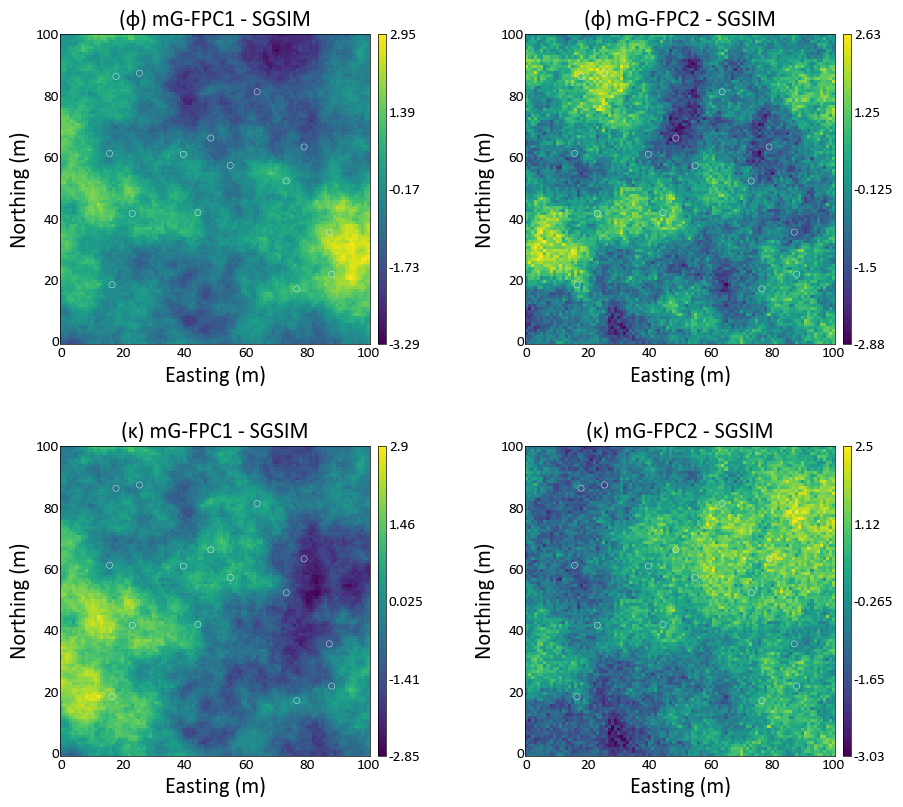

In [114]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
gs.slice_plot(real_poro_dfs[0], 
              var='variable_001', 
              title=f'(φ) mG-FPC1 - SGSIM',
              pointdata=ppmt_poro_fpca_nscore2_2, 
              pointvar='NScore: PC1',
              orient='xy',
              pointkws={'edgecolors':'white'},
              griddef=grid_2d,
              ax=axes[0,0]
             )
gs.slice_plot(real_poro_dfs[0], 
              var='variable_002', 
              title=f'(φ) mG-FPC2 - SGSIM',
              pointdata=ppmt_poro_fpca_nscore2_2, 
              pointvar='NScore: PC2',
              orient='xy',
              pointkws={'edgecolors':'white'},
              griddef=grid_2d,
              ax=axes[0,1]
             )
gs.slice_plot(real_perm_dfs[0], 
              var='variable_001', 
              title=f'(κ) mG-FPC1 - SGSIM',
              pointdata=ppmt_perm_fpca_nscore2_2, 
              pointvar='NScore: PC1',
              orient='xy',
              pointkws={'edgecolors':'white'},
              griddef=grid_2d,
              ax=axes[1,0]
             )
gs.slice_plot(real_perm_dfs[0], 
              var='variable_002', 
              title=f'(κ) mG-FPC2 - SGSIM',
              pointdata=ppmt_perm_fpca_nscore2_2, 
              pointvar='NScore: PC2',
              orient='xy',
              pointkws={'edgecolors':'white'},
              griddef=grid_2d,
              ax=axes[1,1]
             )
plt.subplots_adjust(wspace=0.5)
fig.savefig(f'{path}sgsim_2d.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}sgsim_2d.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


### USGSIM VALIDATION

## Split reals

In [115]:
# PERM
for i, df in enumerate(real_perm_dfs):
    filename = f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real{i}.csv'
    df.to_csv(filename, index=False)


In [116]:
# CSV to GSLIB PERM
for i in range(len(real_perm_dfs)):
    csv_filename = f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real{i}.csv'
    dfl_usgsim_perm_temp = gs.DataFile(csv_filename)
    gs.write_gslib(dfl_usgsim_perm_temp, f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real{i}.out')


In [117]:
dfl_usgsim_perm_temp0 = gs.DataFile('11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real0.out')
dfl_usgsim_perm_temp0 = gs.DataFile('11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real0.csv')
dfl_usgsim_perm_temp0.describe()


,variable_001,variable_002,variable_003,variable_004,variable_005,variable_006,variable_007,variable_008,variable_009,variable_010,variable_011,variable_012
count,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000
mean,-0.160356,-0.077872,0.040512,-0.214192,0.040728,0.138030,-0.197428,-0.113059,-0.116430,0.248296,-0.065875,-0.062194
std,1.008881,0.942960,1.006672,0.956918,0.979427,0.879533,1.030021,0.956699,1.132871,0.951642,1.066576,1.101416
min,-2.841557,-3.028414,-3.632251,-3.284045,-3.917664,-3.165969,-3.655742,-3.333425,-3.551264,-2.993172,-3.605592,-3.341559
25%,-0.857300,-0.794212,-0.638838,-0.835181,-0.605616,-0.483197,-0.914176,-0.777995,-0.886737,-0.399465,-0.777490,-0.874415
50%,-0.189099,-0.029668,0.019879,-0.223304,0.027667,0.135624,-0.220019,-0.113315,-0.071561,0.274939,-0.078283,-0.096958
75%,0.463280,0.633368,0.702434,0.390707,0.703197,0.739603,0.514288,0.543568,0.673901,0.925456,0.628834,0.684337
max,2.894120,2.493167,3.562989,3.260242,3.455230,2.968327,2.700476,3.593985,3.668286,3.218576,4.165194,3.415111


In [118]:
# PORO
for i, df in enumerate(real_poro_dfs):
    filename = f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real{i}.csv'
    df.to_csv(filename, index=False)


In [119]:
# CSV to GSLIB PORO
for i in range(len(real_poro_dfs)):
    csv_filename = f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real{i}.csv'
    dfl_usgsim_poro_temp = gs.DataFile(csv_filename)
    gs.write_gslib(dfl_usgsim_poro_temp, f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real{i}.out') #ERRO 
    print(dfl_usgsim_poro_temp)


11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real0.csv
11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real1.csv


In [120]:
dfl_usgsim_poro_temp0 = gs.DataFile('11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real0.out')
#dfl_usgsim_poro_temp0 = gs.DataFile('11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real0.csv')
dfl_usgsim_poro_temp0.describe()


,variable_001,variable_002,variable_003,variable_004,variable_005,variable_006,variable_007,variable_008,variable_009,variable_010,variable_011,variable_012
count,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000
mean,-0.253975,-0.100708,0.088220,-0.282642,0.051745,0.130787,-0.185096,-0.183369,-0.144716,0.269307,-0.099591,-0.049199
std,1.007109,0.892576,0.900506,1.063647,0.931780,0.936444,1.039256,0.998621,1.083250,0.998887,1.007361,0.996938
min,-3.289048,-2.875131,-2.695047,-2.735691,-2.810919,-3.095306,-3.577664,-3.899339,-3.572112,-3.389776,-3.686695,-3.177669
25%,-0.928538,-0.722326,-0.515675,-1.022095,-0.588239,-0.532539,-0.922827,-0.858395,-0.884832,-0.391518,-0.820638,-0.756934
50%,-0.285490,-0.137569,0.127196,-0.257916,0.033675,0.110807,-0.219729,-0.173629,-0.120976,0.357031,-0.080341,-0.126321
75%,0.407281,0.510470,0.716040,0.338524,0.729471,0.752721,0.548709,0.497825,0.620089,0.995483,0.583332,0.558068
max,2.946793,2.624101,2.865115,3.026950,2.697707,3.666864,3.080522,3.156577,3.108301,3.062894,3.177593,3.480832


In [121]:
dfl_usgsim_perm_temp1 = pd.read_csv('11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real0.csv')
dfl_usgsim_perm_temp1.describe()


,variable_001,variable_002,variable_003,variable_004,variable_005,variable_006,variable_007,variable_008,variable_009,variable_010,variable_011,variable_012
count,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000
mean,-0.160356,-0.077872,0.040512,-0.214192,0.040728,0.138030,-0.197428,-0.113059,-0.116430,0.248296,-0.065875,-0.062194
std,1.008881,0.942960,1.006672,0.956918,0.979427,0.879533,1.030021,0.956699,1.132871,0.951642,1.066576,1.101416
min,-2.841557,-3.028414,-3.632251,-3.284045,-3.917664,-3.165969,-3.655742,-3.333425,-3.551264,-2.993172,-3.605592,-3.341559
25%,-0.857300,-0.794212,-0.638838,-0.835181,-0.605616,-0.483197,-0.914176,-0.777995,-0.886737,-0.399465,-0.777490,-0.874415
50%,-0.189099,-0.029668,0.019879,-0.223304,0.027667,0.135624,-0.220019,-0.113315,-0.071561,0.274939,-0.078283,-0.096958
75%,0.463280,0.633368,0.702434,0.390707,0.703197,0.739603,0.514288,0.543568,0.673901,0.925456,0.628834,0.684337
max,2.894120,2.493167,3.562989,3.260242,3.455230,2.968327,2.700476,3.593985,3.668286,3.218576,4.165194,3.415111


# NScore Back 

## PORO

In [122]:
nscore_b = gs.Program('04-GSlib/nscoremv_b.exe')


for i in range(n_real):
    file_name = f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_real{i}.out'

    par_str = f'''                  Parameters for NSCOREMV_B
                  *************************

    START OF PARAMETERS:
    {file_name}                -  file with data
    6                             -  # of normal var. to back transform
    1 2 3 4 5 6      -  columns for variables
    -1.0e21   1.0e21              -  trimming limits
    12-NScore2_b_defoe/sgsim_nscore2_b_1_poro_real{i}.out                -  file for output
    10-NScore2/poro_nscore2_1_PC1.trn                    -  file with input transformation for var1
    10-NScore2/poro_nscore2_1_PC2.trn                    -  file with input transformation for var2
    10-NScore2/poro_nscore2_1_PC3.trn                  -  file with input transformation for var3
    10-NScore2/poro_nscore2_1_PC4.trn                    -  file with input transformation for var1
    10-NScore2/poro_nscore2_1_PC5.trn                    -  file with input transformation for var2
    10-NScore2/poro_nscore2_1_PC6.trn                  -  file with input transformation for var3
    21 20                     -  minimum and maximum data value for var1
    1    0.0                      -  lower tail option and parameter for var1
    1   2.0                       -  upper tail option and parameter for var1
    41 40                     -  minimum and maximum data value for var2
    1    0.0                      -  lower tail option and parameter for var2
    1   2.0                       -  upper tail option and parameter for var2
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                    -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    '''
    nscore_b.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv_b.exe', 'temp']

 NSCOREMV_B Version: 6.000

  data file = 11-USGSIM_Y_2d_defoe/sgsimY_PCs_poro_rea
  # of var. to back transform =            6
  column #s of normal var. =            1           2           3           4
           5           6
  trimming limits =  -1.0000000E+21  1.0000000E+21
  output file = 12-NScore2_b_defoe/sgsim_nscore2_b_1_por
  transformation file            1  = 10-NScore2/poro_nscore2_1_PC1.trn       
  transformation file            2  = 10-NScore2/poro_nscore2_1_PC2.trn       
  transformation file            3  = 10-NScore2/poro_nscore2_1_PC3.trn       
  transformation file            4  = 10-NScore2/poro_nscore2_1_PC4.trn       
  transformation file            5  = 10-NScore2/poro_nscore2_1_PC5.trn       
  transformation file            6  = 10-NScore2/poro_nscore2_1_PC6.trn       
  data limits for            1  var. =    21.00000       20.00000    
  warning - calculating data limits from trans.table
  data limits =  

In [123]:
data_teste = gs.DataFile('12-NScore2_b_defoe/sgsim_nscore2_b_1_poro_real1.out')
data_teste.describe()


,variable_001,variable_002,variable_003,variable_004,variable_005,variable_006,variable_007,variable_008,variable_009,variable_010,variable_011,variable_012,Nscore_b:variable_001,Nscore_b:variable_002,Nscore_b:variable_003,Nscore_b:variable_004,Nscore_b:variable_005,Nscore_b:variable_006
count,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000,10201.000000
mean,-0.278224,-0.059029,-0.060028,0.185146,0.284676,0.286663,-0.004446,-0.115807,0.003456,-0.039915,0.140828,-0.011494,-1.348280,-0.053605,-0.125680,0.296622,0.527720,0.187024
std,1.059557,0.944043,0.958595,0.803064,0.913709,0.969131,0.968627,1.071266,0.943783,0.980458,0.988654,0.981608,5.696193,1.870034,1.421718,1.175021,1.192068,0.925335
min,-3.184034,-3.259248,-2.844066,-2.010572,-2.448539,-3.305851,-3.210548,-3.328465,-2.895233,-4.089880,-3.030880,-3.175317,-10.553867,-2.961868,-3.574197,-3.427587,-1.807645,-1.697072
25%,-1.035686,-0.708328,-0.772309,-0.424785,-0.348656,-0.344669,-0.663004,-0.863825,-0.706292,-0.664696,-0.506928,-0.738869,-4.851872,-1.729607,-1.051169,-0.316973,-0.701616,-0.372830
50%,-0.272929,-0.063872,-0.144252,0.187995,0.328813,0.278641,0.042156,-0.142203,-0.006658,-0.001752,0.122205,0.001519,-1.110392,0.131649,-0.736461,0.362364,0.866293,0.228984
75%,0.510943,0.597519,0.620256,0.810258,0.880122,0.926683,0.667746,0.573026,0.695053,0.633234,0.787049,0.698149,1.276035,0.973194,1.103295,1.120615,1.613336,0.856189
max,2.629454,2.921664,3.218325,2.145902,3.124523,3.546772,3.266894,4.208536,2.788605,3.041710,3.664869,3.268236,10.149125,4.836042,2.658517,2.539928,1.950107,1.578274


In [124]:
folder_path = '12-NScore2_b_defoe'


file_paths = glob.glob(f'{folder_path}/sgsim_nscore2_b_1_poro_real*.out')

sgsim_nscore2_b_1_poro = {}  

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'real1', 'real2', etc.)
    real = file_path.split('_')[-1].split('.')[0]
    
    sgsim_nscore2_b_1_poro[real] = gs.DataFile(file_path)


In [125]:
nscore_b = gs.Program('04-GSlib/nscoremv_b.exe')


for i in range(n_real):
    file_name = f'12-NScore2_b_defoe/sgsim_nscore2_b_1_poro_real{i}.out'

    par_str = f'''                  Parameters for NSCOREMV_B
                  *************************

    START OF PARAMETERS:
    {file_name}                -  file with data
    6                             -  # of normal var. to back transform
    7 8 9 10 11 12      -  columns for variables
    -1.0e21   1.0e21              -  trimming limits
    12-NScore2_b_defoe/sgsim_nscore2_b_2_poro_real{i}.out                -  file for output
    10-NScore2/poro_nscore2_2_PC7.trn                    -  file with input transformation for var1
    10-NScore2/poro_nscore2_2_PC8.trn                    -  file with input transformation for var2
    10-NScore2/poro_nscore2_2_PC9.trn                  -  file with input transformation for var3
    10-NScore2/poro_nscore2_2_PC10.trn                    -  file with input transformation for var1
    10-NScore2/poro_nscore2_2_PC11.trn                    -  file with input transformation for var2
    10-NScore2/poro_nscore2_2_PC12.trn                  -  file with input transformation for var3
    21 20                     -  minimum and maximum data value for var1
    1    0.0                      -  lower tail option and parameter for var1
    1   2.0                       -  upper tail option and parameter for var1
    41 40                     -  minimum and maximum data value for var2
    1    0.0                      -  lower tail option and parameter for var2
    1   2.0                       -  upper tail option and parameter for var2
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                    -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    '''
    nscore_b.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv_b.exe', 'temp']

 NSCOREMV_B Version: 6.000

  data file = 12-NScore2_b_defoe/sgsim_nscore2_b_1_por
  # of var. to back transform =            6
  column #s of normal var. =            7           8           9          10
          11          12
  trimming limits =  -1.0000000E+21  1.0000000E+21
  output file = 12-NScore2_b_defoe/sgsim_nscore2_b_2_por
  transformation file            1  = 10-NScore2/poro_nscore2_2_PC7.trn       
  transformation file            2  = 10-NScore2/poro_nscore2_2_PC8.trn       
  transformation file            3  = 10-NScore2/poro_nscore2_2_PC9.trn       
  transformation file            4  = 10-NScore2/poro_nscore2_2_PC10.trn      
  transformation file            5  = 10-NScore2/poro_nscore2_2_PC11.trn      
  transformation file            6  = 10-NScore2/poro_nscore2_2_PC12.trn      
  data limits for            1  var. =    21.00000       20.00000    
  warning - calculating data limits from trans.table
  data limits =  

In [126]:
folder_path = '12-NScore2_b_defoe'

# Get a list of all files in the folder with the pattern 'poro_nscore2_PC*.out'
file_paths = glob.glob(f'{folder_path}/sgsim_nscore2_b_2_poro_real*.out')

sgsim_nscore2_b_2_poro = {}  # Dictionary to store the DataFile objects with variable names as keys

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'real1', 'real2', etc.)
    real = file_path.split('_')[-1].split('.')[0]
    
    sgsim_nscore2_b_2_poro[real] = gs.DataFile(file_path, tmin=-1.0e21)
    
    columns_to_drop = ['variable_001', 'variable_002', 'variable_003', 'variable_004', 'variable_005', 'variable_006', 'variable_007', 'variable_008', 'variable_009', 'variable_010', 'variable_011', 'variable_012']
    sgsim_nscore2_b_2_poro[real].data.drop(columns=columns_to_drop, inplace=True)


## PERM

In [127]:
nscore_b = gs.Program('04-GSlib/nscoremv_b.exe')


for i in range(n_real):
    file_name = f'11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_real{i}.out'

    par_str = f'''                  Parameters for NSCOREMV_B
                  *************************

    START OF PARAMETERS:
    {file_name}                -  file with data
    6                             -  # of normal var. to back transform
    1 2 3 4 5 6     -  columns for variables
    -1.0e21   1.0e21              -  trimming limits
    12-NScore2_b_defoe/sgsim_nscore2_b_1_perm_real{i}.out                -  file for output
    10-NScore2/perm_nscore2_1_PC1.trn                   -  file with input transformation for var1
    10-NScore2/perm_nscore2_1_PC2.trn                   -  file with input transformation for var2
    10-NScore2/perm_nscore2_1_PC3.trn                 -  file with input transformation for var3
    10-NScore2/perm_nscore2_1_PC4.trn                   -  file with input transformation for var1
    10-NScore2/perm_nscore2_1_PC5.trn                   -  file with input transformation for var2
    10-NScore2/perm_nscore2_1_PC6.trn                 -  file with input transformation for var3
    21 20                     -  minimum and maximum data value for var1
    1    0.0                      -  lower tail option and parameter for var1
    1   2.0                       -  upper tail option and parameter for var1
    41 40                     -  minimum and maximum data value for var2
    1    0.0                      -  lower tail option and parameter for var2
    1   2.0                       -  upper tail option and parameter for var2
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                    -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    '''
    nscore_b.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv_b.exe', 'temp']

 NSCOREMV_B Version: 6.000

  data file = 11-USGSIM_Y_2d_defoe/sgsimY_PCs_perm_rea
  # of var. to back transform =            6
  column #s of normal var. =            1           2           3           4
           5           6
  trimming limits =  -1.0000000E+21  1.0000000E+21
  output file = 12-NScore2_b_defoe/sgsim_nscore2_b_1_per
  transformation file            1  = 10-NScore2/perm_nscore2_1_PC1.trn       
  transformation file            2  = 10-NScore2/perm_nscore2_1_PC2.trn       
  transformation file            3  = 10-NScore2/perm_nscore2_1_PC3.trn       
  transformation file            4  = 10-NScore2/perm_nscore2_1_PC4.trn       
  transformation file            5  = 10-NScore2/perm_nscore2_1_PC5.trn       
  transformation file            6  = 10-NScore2/perm_nscore2_1_PC6.trn       
  data limits for            1  var. =    21.00000       20.00000    
  warning - calculating data limits from trans.table
  data limits =  

In [128]:
folder_path = '12-NScore2_b_defoe'

# Get a list of all files in the folder with the pattern 'poro_nscore2_PC*.out'
file_paths = glob.glob(f'{folder_path}/sgsim_nscore2_b_1_perm_real*.out')

sgsim_nscore2_b_1_perm = {}  # Dictionary to store the DataFile objects with variable names as keys

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'real1', 'real2', etc.)
    real = file_path.split('_')[-1].split('.')[0]
    
    sgsim_nscore2_b_1_perm[real] = gs.DataFile(file_path, tmin=-1.0e21)


In [129]:
nscore_b = gs.Program('04-GSlib/nscoremv_b.exe')

for i in range(n_real):
    file_name = f'12-NScore2_b_defoe/sgsim_nscore2_b_1_perm_real{i}.out'

    par_str = f'''                  Parameters for NSCOREMV_B
                  *************************

    START OF PARAMETERS:
    {file_name}                -  file with data
    6                             -  # of normal var. to back transform
    7 8 9 10 11 12     -  columns for variables
    -1.0e21   1.0e21              -  trimming limits
    12-NScore2_b_defoe/sgsim_nscore2_b_2_perm_real{i}.out                -  file for output
    10-NScore2/perm_nscore2_2_PC7.trn                   -  file with input transformation for var1
    10-NScore2/perm_nscore2_2_PC8.trn                   -  file with input transformation for var2
    10-NScore2/perm_nscore2_2_PC9.trn                 -  file with input transformation for var3
    10-NScore2/perm_nscore2_2_PC10.trn                   -  file with input transformation for var1
    10-NScore2/perm_nscore2_2_PC11.trn                   -  file with input transformation for var2
    10-NScore2/perm_nscore2_2_PC12.trn                 -  file with input transformation for var3
    21 20                     -  minimum and maximum data value for var1
    1    0.0                      -  lower tail option and parameter for var1
    1   2.0                       -  upper tail option and parameter for var1
    41 40                     -  minimum and maximum data value for var2
    1    0.0                      -  lower tail option and parameter for var2
    1   2.0                       -  upper tail option and parameter for var2
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                    -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    91 90                     -  minimum and maximum data value for var3
    1    0.0                      -  lower tail option and parameter for var3
    1   2.0                       -  upper tail option and parameter for var3
    '''
    nscore_b.run(parstr=par_str)


Calling:  ['04-GSlib/nscoremv_b.exe', 'temp']

 NSCOREMV_B Version: 6.000

  data file = 12-NScore2_b_defoe/sgsim_nscore2_b_1_per
  # of var. to back transform =            6
  column #s of normal var. =            7           8           9          10
          11          12
  trimming limits =  -1.0000000E+21  1.0000000E+21
  output file = 12-NScore2_b_defoe/sgsim_nscore2_b_2_per
  transformation file            1  = 10-NScore2/perm_nscore2_2_PC7.trn       
  transformation file            2  = 10-NScore2/perm_nscore2_2_PC8.trn       
  transformation file            3  = 10-NScore2/perm_nscore2_2_PC9.trn       
  transformation file            4  = 10-NScore2/perm_nscore2_2_PC10.trn      
  transformation file            5  = 10-NScore2/perm_nscore2_2_PC11.trn      
  transformation file            6  = 10-NScore2/perm_nscore2_2_PC12.trn      
  data limits for            1  var. =    21.00000       20.00000    
  warning - calculating data limits from trans.table
  data limits =  

In [130]:
folder_path = '12-NScore2_b_defoe'

# Get a list of all files in the folder with the pattern 'poro_nscore2_PC*.out'
file_paths = glob.glob(f'{folder_path}/sgsim_nscore2_b_2_perm_real*.out')

sgsim_nscore2_b_2_perm = {}  # Dictionary to store the DataFile objects with variable names as keys

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'real1', 'real2', etc.)
    real = file_path.split('_')[-1].split('.')[0]
    
    sgsim_nscore2_b_2_perm[real] = gs.DataFile(file_path, tmin=-1.0e21)
    
    columns_to_drop = ['variable_001', 'variable_002', 'variable_003', 'variable_004', 'variable_005', 'variable_006', 'variable_007', 'variable_008', 'variable_009', 'variable_010', 'variable_011', 'variable_012']
    sgsim_nscore2_b_2_perm[real].data.drop(columns=columns_to_drop, inplace=True)


# PCA Back

## PORO

In [131]:
pca_back_poro_dict = {}
df_pca_b_poro_dict = {}
output_filename_dict = {}

for real in sgsim_nscore2_b_2_poro:
    pca_back_poro_dict[real] = pca_poro.inverse_transform(sgsim_nscore2_b_2_poro[real].data.values)
    df_pca_b_poro_dict[real] = pd.DataFrame(pca_back_poro_dict[real], columns=coef)
    output_filename_dict[real] = f'13-FPCA_b/pca_b_poro_{real}.dat'
    df_pca_b_poro_dict[real].to_csv(output_filename_dict[real], index=False)
    print(f'Saved {output_filename_dict[real]}')


Saved 13-FPCA_b/pca_b_poro_real0.dat
Saved 13-FPCA_b/pca_b_poro_real1.dat
Saved 13-FPCA_b/pca_b_poro_real10.dat
Saved 13-FPCA_b/pca_b_poro_real12.dat
Saved 13-FPCA_b/pca_b_poro_real14.dat
Saved 13-FPCA_b/pca_b_poro_real15.dat
Saved 13-FPCA_b/pca_b_poro_real16.dat
Saved 13-FPCA_b/pca_b_poro_real19.dat
Saved 13-FPCA_b/pca_b_poro_real20.dat
Saved 13-FPCA_b/pca_b_poro_real24.dat
Saved 13-FPCA_b/pca_b_poro_real27.dat
Saved 13-FPCA_b/pca_b_poro_real29.dat
Saved 13-FPCA_b/pca_b_poro_real6.dat


## PERM

In [132]:
pca_back_perm_dict = {}
df_pca_b_perm_dict = {}
output_filename_dict = {}

for real in sgsim_nscore2_b_2_perm:
    pca_back_perm_dict[real] = pca_perm.inverse_transform(sgsim_nscore2_b_2_perm[real].data.values)
    df_pca_b_perm_dict[real] = pd.DataFrame(pca_back_perm_dict[real], columns=coef)
    output_filename_dict[real] = f'13-FPCA_b/pca_b_perm_{real}.dat'
    df_pca_b_perm_dict[real].to_csv(output_filename_dict[real], index=False)
    print(f'Saved {output_filename_dict[real]}')


Saved 13-FPCA_b/pca_b_perm_real0.dat
Saved 13-FPCA_b/pca_b_perm_real1.dat
Saved 13-FPCA_b/pca_b_perm_real10.dat
Saved 13-FPCA_b/pca_b_perm_real11.dat
Saved 13-FPCA_b/pca_b_perm_real12.dat
Saved 13-FPCA_b/pca_b_perm_real14.dat
Saved 13-FPCA_b/pca_b_perm_real15.dat
Saved 13-FPCA_b/pca_b_perm_real16.dat
Saved 13-FPCA_b/pca_b_perm_real17.dat
Saved 13-FPCA_b/pca_b_perm_real18.dat
Saved 13-FPCA_b/pca_b_perm_real19.dat
Saved 13-FPCA_b/pca_b_perm_real20.dat
Saved 13-FPCA_b/pca_b_perm_real21.dat
Saved 13-FPCA_b/pca_b_perm_real22.dat
Saved 13-FPCA_b/pca_b_perm_real23.dat
Saved 13-FPCA_b/pca_b_perm_real24.dat
Saved 13-FPCA_b/pca_b_perm_real25.dat
Saved 13-FPCA_b/pca_b_perm_real26.dat
Saved 13-FPCA_b/pca_b_perm_real27.dat
Saved 13-FPCA_b/pca_b_perm_real28.dat
Saved 13-FPCA_b/pca_b_perm_real29.dat
Saved 13-FPCA_b/pca_b_perm_real3.dat
Saved 13-FPCA_b/pca_b_perm_real30.dat
Saved 13-FPCA_b/pca_b_perm_real31.dat
Saved 13-FPCA_b/pca_b_perm_real5.dat
Saved 13-FPCA_b/pca_b_perm_real6.dat
Saved 13-FPCA_b/p

# Back Transpose

## PORO

In [133]:
back_transp_poro_dict = {}

for real in df_pca_b_poro_dict:
    back_transp_poro_dict[real] = df_pca_b_poro_dict[real].transpose()
    output_filename = f'13-FPCA_b/back_transpose_poro_{real}.dat'
    back_transp_poro_dict[real].to_csv(output_filename, index=False)
    print(f'Saved {output_filename}')


Saved 13-FPCA_b/back_transpose_poro_real0.dat
Saved 13-FPCA_b/back_transpose_poro_real1.dat
Saved 13-FPCA_b/back_transpose_poro_real10.dat
Saved 13-FPCA_b/back_transpose_poro_real12.dat
Saved 13-FPCA_b/back_transpose_poro_real14.dat
Saved 13-FPCA_b/back_transpose_poro_real15.dat
Saved 13-FPCA_b/back_transpose_poro_real16.dat
Saved 13-FPCA_b/back_transpose_poro_real19.dat
Saved 13-FPCA_b/back_transpose_poro_real20.dat
Saved 13-FPCA_b/back_transpose_poro_real24.dat
Saved 13-FPCA_b/back_transpose_poro_real27.dat
Saved 13-FPCA_b/back_transpose_poro_real29.dat
Saved 13-FPCA_b/back_transpose_poro_real6.dat


## PERM

In [134]:
back_transp_perm_dict = {}

for real in df_pca_b_perm_dict:
    back_transp_perm_dict[real] = df_pca_b_perm_dict[real].transpose()
    output_filename = f'13-FPCA_b/back_transpose_perm_{real}.dat'
    back_transp_perm_dict[real].to_csv(output_filename, index=False)
    print(f'Saved {output_filename}')


Saved 13-FPCA_b/back_transpose_perm_real0.dat
Saved 13-FPCA_b/back_transpose_perm_real1.dat
Saved 13-FPCA_b/back_transpose_perm_real10.dat
Saved 13-FPCA_b/back_transpose_perm_real11.dat
Saved 13-FPCA_b/back_transpose_perm_real12.dat
Saved 13-FPCA_b/back_transpose_perm_real14.dat
Saved 13-FPCA_b/back_transpose_perm_real15.dat
Saved 13-FPCA_b/back_transpose_perm_real16.dat
Saved 13-FPCA_b/back_transpose_perm_real17.dat
Saved 13-FPCA_b/back_transpose_perm_real18.dat
Saved 13-FPCA_b/back_transpose_perm_real19.dat
Saved 13-FPCA_b/back_transpose_perm_real20.dat
Saved 13-FPCA_b/back_transpose_perm_real21.dat
Saved 13-FPCA_b/back_transpose_perm_real22.dat
Saved 13-FPCA_b/back_transpose_perm_real23.dat
Saved 13-FPCA_b/back_transpose_perm_real24.dat
Saved 13-FPCA_b/back_transpose_perm_real25.dat
Saved 13-FPCA_b/back_transpose_perm_real26.dat
Saved 13-FPCA_b/back_transpose_perm_real27.dat
Saved 13-FPCA_b/back_transpose_perm_real28.dat
Saved 13-FPCA_b/back_transpose_perm_real29.dat
Saved 13-FPCA_b

# Revel to one column

## Grid 3d

In [135]:
grid_3d = gs.GridDef('''101   0.0    1.0               -nx,xmn,xsiz
101   0.0    1.0               -ny,ymn,ysiz
89    0.0    1.0               -nz,zmn,zsiz ''')


## PORO

In [136]:
poro_revel_array_dict = {}
poro_revel_df_dict = {}
poro_revel_dfl_dict = {}

for real in back_transp_poro_dict:
    poro_revel_array_dict[real] = np.ravel(back_transp_poro_dict[real].values, order='c')
    poro_revel_df_dict[real] = pd.DataFrame(poro_revel_array_dict[real], columns=['Simulate_Poro'])
    gs.write_gslib(poro_revel_df_dict[real], f'14-USGSIM_Y_3d/df_sim_poro_{real}.out')
    poro_revel_dfl_dict[real] = gs.DataFile(f'14-USGSIM_Y_3d/df_sim_poro_{real}.out', griddef=grid_3d)


## PERM

In [137]:
perm_revel_array_dict = {}
perm_revel_df_dict = {}
perm_revel_dfl_dict = {}

for real in back_transp_perm_dict:
    perm_revel_array_dict[real] = np.ravel(back_transp_perm_dict[real].values, order='c')
    perm_revel_df_dict[real] = pd.DataFrame(perm_revel_array_dict[real], columns=['Simulate_Perm'])
    gs.write_gslib(perm_revel_df_dict[real], f'14-USGSIM_Y_3d/df_sim_perm_{real}.out')
    perm_revel_dfl_dict[real] = gs.DataFile(f'14-USGSIM_Y_3d/df_sim_perm_{real}.out', griddef=grid_3d)


## Concat PORO e PERM

In [141]:
df_sim_poro_perm_dict = {}

for real in perm_revel_dfl_dict and poro_revel_dfl_dict:
    df_sim_poro_perm_dict[real] = pd.concat([poro_revel_dfl_dict[real].data, perm_revel_dfl_dict[real].data], axis=1)
    print(f'df_sim_poro_perm_dict{real}')


df_sim_poro_perm_dictreal0
df_sim_poro_perm_dictreal1
df_sim_poro_perm_dictreal10
df_sim_poro_perm_dictreal12
df_sim_poro_perm_dictreal14
df_sim_poro_perm_dictreal15
df_sim_poro_perm_dictreal16
df_sim_poro_perm_dictreal19
df_sim_poro_perm_dictreal20
df_sim_poro_perm_dictreal24
df_sim_poro_perm_dictreal27
df_sim_poro_perm_dictreal29
df_sim_poro_perm_dictreal6


# PPMT Back

In [142]:
grid_3d.nx * grid_3d.ny * grid_3d.nz 


907889

In [143]:
simY_poro_perm_dict = {}

for real in df_sim_poro_perm_dict:
    gs.write_gslib(df_sim_poro_perm_dict[real], f'14-USGSIM_Y_3d/df_sim_poro_perm_{real}.out')
    simY_poro_perm_dict[real] = gs.DataFile(f'14-USGSIM_Y_3d/df_sim_poro_perm_{real}.out')


In [144]:
ppmt_b = gs.Program('04-GSlib/ppmt_b.exe')

for real in simY_poro_perm_dict:
    par_str = f'''                 PPMT Back Transformation
                     ************************

    START OF PARAMETERS:
    04-PPMT/ppmt_w.trn                      -file with transformation data
    {simY_poro_perm_dict[real]}                     -file with data to back-transform (GSB detection)
    2 {simY_poro_perm_dict[real].gscol('Simulate_Poro')} {simY_poro_perm_dict[real].gscol('Simulate_Perm')}                           - nvar, column numbers
    -1.0e21     1.0e21                   - trimming limits
    {grid_3d.nx} {grid_3d.ny} {grid_3d.nz} {n_real}                   - nx, ny, nz, nreal (ignored if nx = 0)
    15-PPMT_b/sgsim_ppmt_b_{real}.out                    -file for back transformed values
    0                             -enforce N(0,1)? (0=no,1=yes)
    -----------------------------------------------------------------
         Disregard the following lines if not enforcing N(0,1) 
    -----------------------------------------------------------------
    1                             -consider local uncertainty? (0=no,1=yes)
    kt3dv.out                     - local file
    1 2                           -  columns for kriging variances
    .2                            -  weight factor
    5                             -  number of loops


    '''
    ppmt_b.run(parstr=par_str)


Calling:  ['04-GSlib/ppmt_b.exe', 'temp']

 PPMT_B Reverse Projection version: 3.201

 transformation file = 04-PPMT/ppmt_w.trn
 GSLIB-style data file = 14-USGSIM_Y_3d/df_sim_poro_perm_real0.ou
 number of variables =    2
 cols. for transformed vars. =     1    2
 trimming limits =  ******* .10E+22
 nx, ny, nz, nreal =       101      101       89        2
 output file = 15-PPMT_b/sgsim_ppmt_b_real0.out
 enforce N(0,1)? =   0
 working on realization:  1
 working on realization:  2
forrtl: severe (24): end-of-file during read, unit 2, file c:\Users\Bernardo.Silveira\OneDrive\Publications\PPMT-FDA-SGSIM\Code-edit\14-USGSIM_Y_3d\df_sim_poro_perm_real0.out

Image              PC                Routine            Line        Source             
ppmt_b.exe         00000001400DF505  Unknown               Unknown  Unknown
ppmt_b.exe         00000001400DAFB9  Unknown               Unknown  Unknown
ppmt_b.exe         0000000140079E3F  Unknown               Unknown  Unknown
ppmt_b.exe         0000

In [145]:
folder_path = '15-PPMT_b'

# Get a list of all files in the folder with the pattern 'poro_nscore2_PC*.out'
file_paths = glob.glob(f'{folder_path}/sgsim_ppmt_b_real*.out')

sgsim_ppmt_b_dict = {}  # Dictionary to store the DataFile objects with variable names as keys

for file_path in file_paths:
    # Extract the variable name from the file path (e.g., 'real1', 'real2', etc.)
    real = file_path.split('_')[-1].split('.')[0]
    
    sgsim_ppmt_b_dict[real] = gs.DataFile(file_path, griddef=grid_3d)


In [146]:
sgsim_ppmt_b_dict['real0'].data


,PPMT_B:Simulate_Poro,PPMT_B:Simulate_Perm
0,0.206,515.56318
1,0.205,525.12802
2,0.205,527.29037
3,0.205,526.22559
4,0.206,512.39934
...,...,...
907884,0.180,616.09332
907885,0.188,644.58838
907886,0.196,666.19133
907887,0.201,685.05389


# Validation

In [147]:
first_reals = list(sgsim_ppmt_b_dict.keys())[:4]
print(first_reals)


['real0', 'real1', 'real10', 'real12']


## Visual Validation

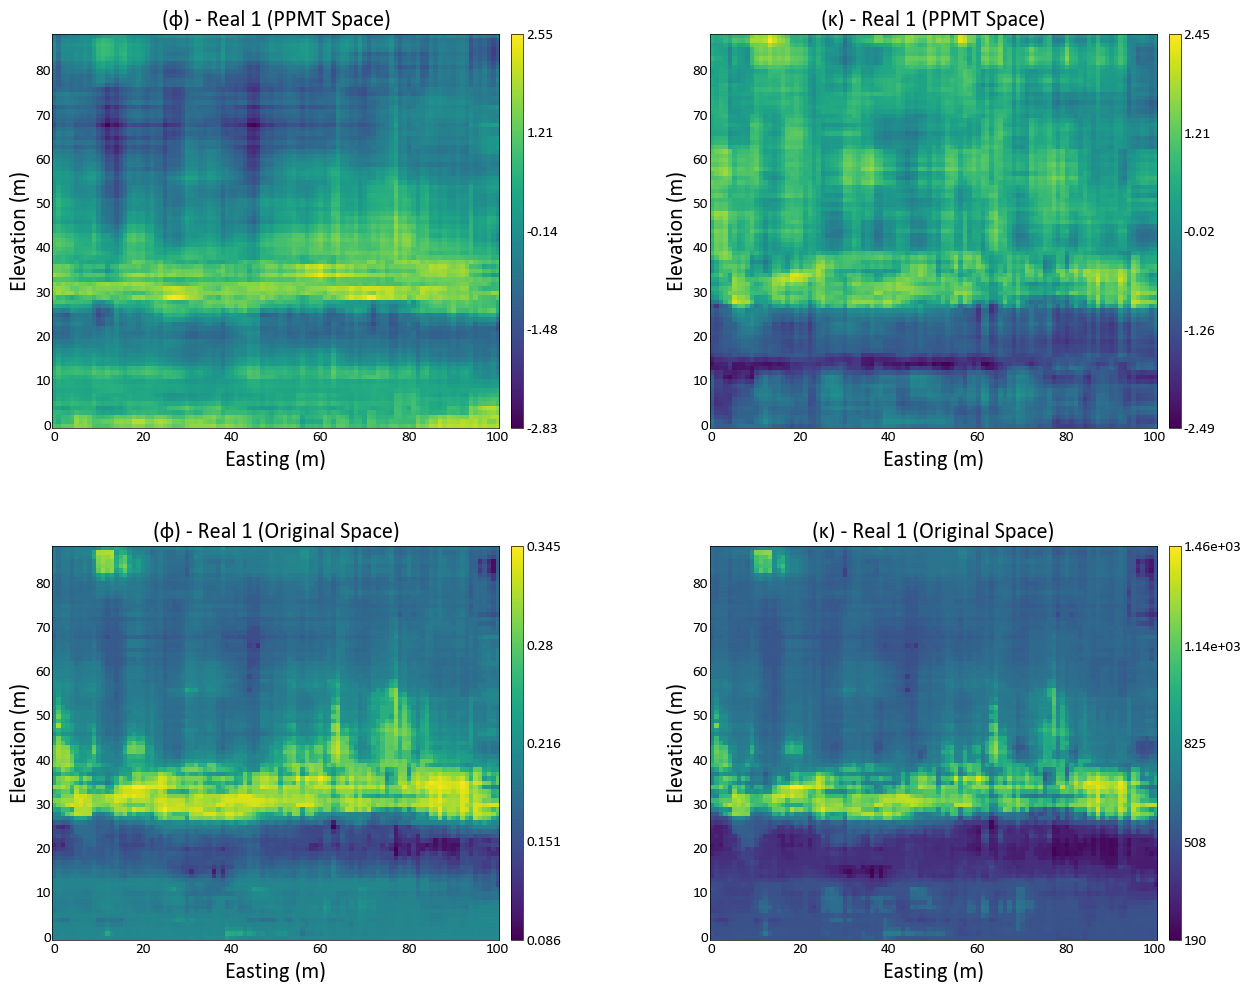

In [ ]:
# Compare PPMT Space vs Back Transformed Realizations
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# PPMT Space - Porosity (φ)
gs.slice_plot(poro_revel_dfl_dict['real1'], 
              orient='xz', 
              title='(φ) - Real 1 (PPMT Space)',
              cbar=True,
              ax=axes[0,0]
             )

# PPMT Space - Permeability (κ)
gs.slice_plot(perm_revel_dfl_dict['real1'], 
              orient='xz', 
              title='(κ) - Real 1 (PPMT Space)',
              cbar=True,
              ax=axes[0,1]
             )

# Back Transformed - Porosity (φ)
gs.slice_plot(sgsim_ppmt_b_dict['real1'], 
              var='PPMT_B:Simulate_Poro',
              orient='xz', 
              title='(φ) - Real 1 (Cartesian Space)',
              cbar=True,
              ax=axes[1,0]
             )

# Back Transformed - Permeability (κ)
gs.slice_plot(sgsim_ppmt_b_dict['real1'], 
              var='PPMT_B:Simulate_Perm',
              orient='xz', 
              title='(κ) - Real 1 (Cartesian Space)',
              cbar=True,
              ax=axes[1,1]
             )

plt.subplots_adjust(wspace=0.3, hspace=0.3)
fig.savefig(f'{path}real1_ppmt_vs_backtransform.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}real1_ppmt_vs_backtransform.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


## Scatter Plot

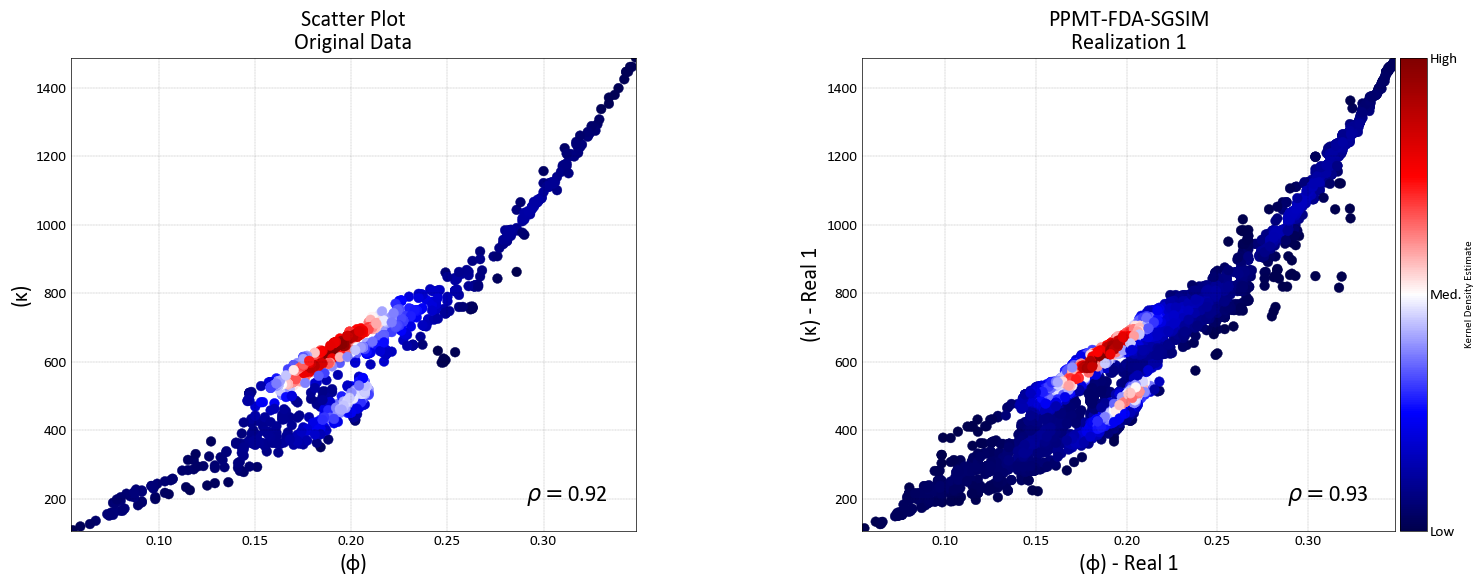

In [161]:
cmap='seismic'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original Data
gs.scatter_plot(data['Poro'], 
                data['Perm'], 
                grid=True, 
                title='Scatter Plot\nOriginal Data',
                xlabel='(φ)',
                ylabel='(κ)',
                cmap=cmap,
                ax=axes[0],      
               )

# PPMT-FDA-SGSIM Realization 1
gs.scatter_plot(sgsim_ppmt_b_dict[first_real]['PPMT_B:Simulate_Poro'], 
                sgsim_ppmt_b_dict[first_real]['PPMT_B:Simulate_Perm'], 
                grid=True, 
                title='PPMT-FDA-SGSIM\nRealization 1',
                xlabel='(φ) - Real 1',
                ylabel='(κ) - Real 1',
                cmap=cmap,
                nmax=10000,
                cbar=True,
                ax=axes[1],      
               )
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
fig.savefig(f'{path}scatterplot_validation.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}scatterplot_validation.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


## Histogram Validation

#### Criando DF contendo as simulações de cada variável

In [163]:
reals_poro_df = pd.DataFrame()
reals_perm_df = pd.DataFrame()


for key, datafile in sgsim_ppmt_b_dict.items():

    Simulate_poro = datafile['PPMT_B:Simulate_Poro']
    Simulate_perm = datafile['PPMT_B:Simulate_Perm']
    

    reals_poro_df[key] = Simulate_poro
    reals_perm_df[key] = Simulate_perm


print("Reals Poro DataFrame:")
print(reals_poro_df)

print("Reals Perm DataFrame:")
print(reals_perm_df)


Reals Poro DataFrame:
        real0  real1  real10    real12  real13    real14  real15    real16  \
0       0.206  0.206   0.207  0.196000   0.207  0.207000   0.195  0.206000   
1       0.205  0.206   0.207  0.204000   0.208  0.206000   0.204  0.206000   
2       0.205  0.206   0.208  0.203000   0.209  0.207000   0.206  0.206000   
3       0.205  0.206   0.212  0.204871   0.207  0.213000   0.207  0.205000   
4       0.206  0.206   0.224  0.205000   0.207  0.233564   0.207  0.199000   
...       ...    ...     ...       ...     ...       ...     ...       ...   
907884  0.180  0.189   0.179  0.197000   0.191  0.178000   0.183  0.178000   
907885  0.188  0.194   0.196  0.196000   0.181  0.170000   0.183  0.155831   
907886  0.196  0.194   0.184  0.196063   0.183  0.173000   0.184  0.167000   
907887  0.201  0.193   0.191  0.198000   0.190  0.173000   0.182  0.188000   
907888  0.202  0.193   0.195  0.186000   0.189  0.177000   0.181  0.192000   

        real17  real18  ...    real28    

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


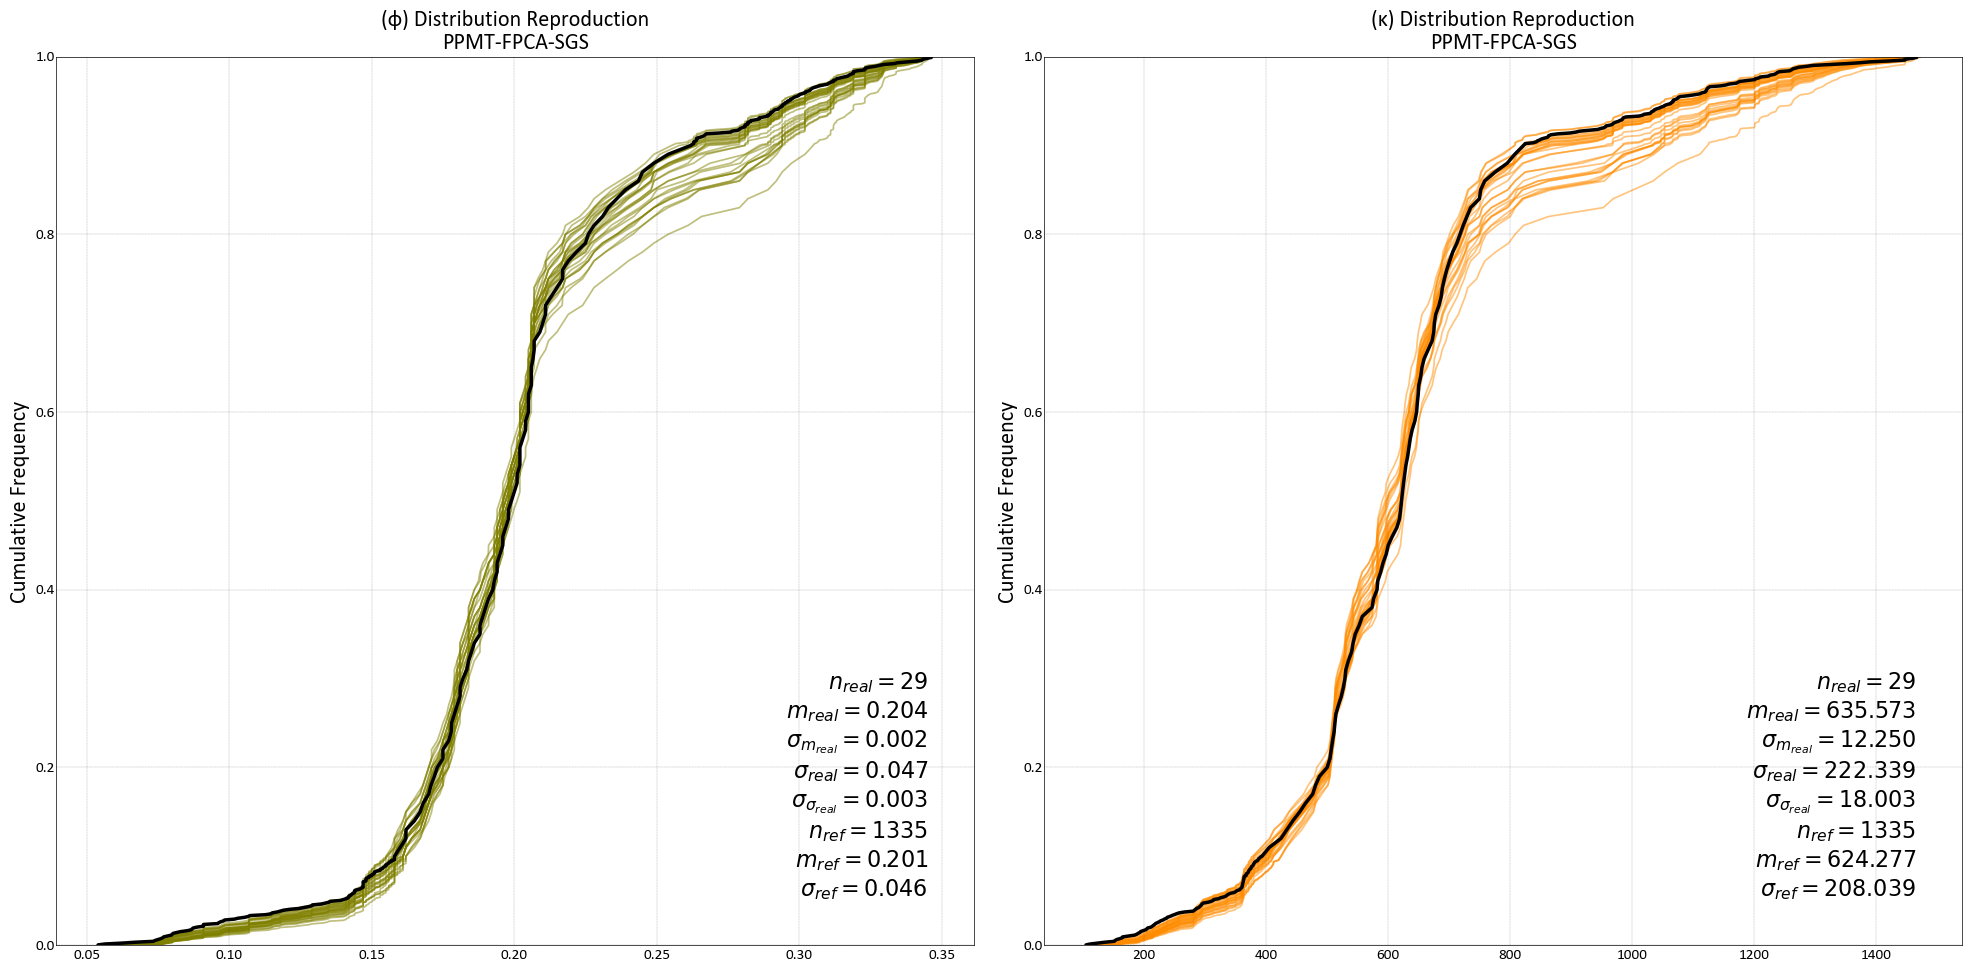

In [167]:
# Histogram reproduction validation - Simulated vs Reference data
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Porosity (φ) histogram
gs.histogram_plot_simulation(simulated_data=reals_poro_df, 
                             simulation_color=color_poro,
                             reference_color='black',
                             grid=True,
                             reference_data=data_declus, 
                             reference_variable='Poro', 
                             alpha=0.5,
                             lw=2.5,
                             nreal=n_real, 
                             griddef=grid_3d,
                             title='(φ) Distribution Reproduction\nPPMT-FPCA-SGS', 
                             stat_fontsize=12,
                             ax=axes[0]
                            )

# Permeability (κ) histogram
gs.histogram_plot_simulation(simulated_data=reals_perm_df, 
                             simulation_color=color_perm,
                             reference_color='black',
                             grid=True,
                             reference_data=data_declus, 
                             reference_variable='Perm', 
                             alpha=0.5,
                             lw=2.5,
                             nreal=n_real, 
                             griddef=grid_3d,
                             title='(κ) Distribution Reproduction\nPPMT-FPCA-SGS', 
                             stat_fontsize=12,
                             ax=axes[1]
                            )

plt.tight_layout()
fig.savefig(f'{path}hist_reproduction.eps', format='eps', bbox_inches='tight')
fig.savefig(f'{path}hist_reproduction.tif', format='tiff', dpi=600, bbox_inches='tight')
plt.show()


In [168]:
data_poro = pd.DataFrame(data_declus['Poro'])


In [169]:
n_samples = len(sgsim_ppmt_b_dict['real0']['PPMT_B:Simulate_Poro'])
k_sim = round(1 + 3.322 * np.log(n_samples))
print(f'Número de amostras: {n_samples}')
print(f'Valor de k: {k_sim}')


Número de amostras: 907889
Valor de k: 47


In [170]:
n_samples = len(data_declus['Poro'])
k_data = round(1 + 3.322 * np.log(n_samples))
print(f'Número de amostras: {n_samples}')
print(f'Valor de k: {k_data}')


Número de amostras: 1335
Valor de k: 25


In [171]:
# # Configurações iniciais
# plt.figure(figsize=(12, 10))  # Aumentando o tamanho da figura para acomodar ambos os subplots
# sns.set(style="whitegrid", rc={"grid.color": ".9"})

# # Histograma para 'poro'
# plt.subplot(2, 1, 1)  # Duas linhas, uma coluna, posição 1
# sns.histplot(sgsim_ppmt_b_dict['real0']['PPMT_B:Simulate_Poro'], color=color_poro, label='Realização-1', bins=k_sim, kde=False, stat="density", linewidth=0)
# sns.histplot(data_declus['Poro'], color='slategray', label='Dados Declusterizados', bins=k_data, kde=False, stat="density", linewidth=0, alpha=0.4)
# plt.legend()
# plt.title('Realização 1 vs Dados Originais - Porosidade', fontsize=16)
# plt.xlabel('Distribuições', fontsize=14)
# plt.ylabel('Porosidade', fontsize=14)

# # Histograma para 'perm'
# plt.subplot(2, 1, 2)  # Duas linhas, uma coluna, posição 2
# sns.histplot(sgsim_ppmt_b_dict['real0']['PPMT_B:Simulate_Perm'], color=color_perm, label='Realização-1', bins=k_sim, kde=False, stat="density", linewidth=0)
# sns.histplot(data_declus['Perm'], color='slategray', label='Dados Declusterizados', bins=k_data, kde=False, stat="density", linewidth=0, alpha=0.4)
# plt.legend()
# plt.title('Realização 1 vs Dados Originais - Permeabilidade', fontsize=16)
# plt.xlabel('Distribuições', fontsize=14)
# plt.ylabel('Permeabilidade', fontsize=14)

# plt.tight_layout() 
# plt.savefig(f'{path}sim_distributions_validation')
# plt.show()


## Variogram Validation

## PORO

In [172]:
# Transforming in GSLIB
#poro
reals_poro_df.to_csv('17-Validation/reals_poro_df.csv')
temp = gs.DataFile('17-Validation/reals_poro_df.csv')
temp.drop(columns=['Unnamed: 0'])
gs.write_gslib(temp, '17-Validation/reals_poro_df.dat')
reals_poro_dfl = gs.DataFile('17-Validation/reals_poro_df.dat')


In [173]:
# Transforming in GSLIB
#perm
reals_perm_df.to_csv('17-Validation/reals_perm_df.csv')
temp = gs.DataFile('17-Validation/reals_perm_df.csv')
temp.drop(columns=['Unnamed: 0'])
gs.write_gslib(temp, '17-Validation/reals_perm_df.dat')
reals_perm_dfl = gs.DataFile('17-Validation/reals_perm_df.dat')


In [ ]:
varsim = gs.Program('04-GSlib/varsim.exe')

reals = reals_poro_df.columns

for i in range(n_real):
    par_str = f'''                 Parameters for VarSim
                 *********************

START OF PARAMETERS:
../data/lithology.dat        -file with lithology information
0   7                        -   lithology column (0=not used), code
{reals_poro_dfl}      -file with data
1   {reals_poro_dfl.gscol(f'real{i}')}                -   number of variables, column numbers
-98     1.0e21    -   trimming limits
17-Validation/varsim_real{i}_poro.out      -output file for variograms of realizations
17-Validation/varsim_poro_avg.out        -output file for average variogram
{grid_3d}
{n_real}                  -number of realizations
2  100                 -number of directions, number of lags
 1  0  0              -ixd(1),iyd(1),izd(1)
 0  0  -1              -ixd(2),iyd(2),izd(2)
1                     -standardize sill? (0=no, 1=yes)
1                     -number of variograms
1   1   1             -tail variable, head variable, variogram type


type 1 = traditional semivariogram
     2 = traditional cross semivariogram
     3 = covariance
     4 = correlogram
     5 = general relative semivariogram
     6 = pairwise relative semivariogram
     7 = semivariogram of logarithms
     8 = semimadogram
     9 = indicator semivariogram - continuous
     10= indicator semivariogram - categorical


VarSim is a conversion of gamsim_ave to support
the file format used by varcalc, varmodel and varplot.

'''
    varsim.run(parstr=par_str)


Calling:  ['04-GSlib/varsim.exe', 'temp']

 VarSim (conversion of gamsim_ave) Version: 1.500

  GSLIB-style lithology file = ../data/lithology.dat                   
  lithology column, code =            0           7
  GSLIB-style data file = 17-Validation/reals_poro_df.dat         
  number of variables =            1
  columns =            1
  trimming limits =   -98.00000      1.0000000E+21
  output file = 17-Validation/varsim_real0_poro.out     
  output file for average = 17-Validation/varsim_poro_avg.out       
  nx,xmn,xsiz =          101  0.0000000E+00   1.000000    
  ny,ymn,ysiz =          101  0.0000000E+00   1.000000    
  nz,zmn,zsiz =           89  0.0000000E+00   1.000000    
  nreal =            2
  ndir,nlag =            2         100
  direction =            1           0           0
  direction =            0           0          -1
  flag to standardize sills =            1
  number of variograms =            1
  tail,head,type =            1           1           

In [ ]:
# fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# # Primeiro plot para index=1
# legend_real = mlines.Line2D([], [], color=color_poro, linestyle='-', linewidth=2, label='Reals')
# legend_exp = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Pontos experimentais')

# for i in range(n_real):
#     i_real = i
#     outvarsimreals_poro = f'17-Validation/varsim_real{i_real}_poro.out'
#     varsim_file_poro = gs.DataFile(outvarsimreals_poro, griddef=grid_3d)
#     varsim_df_poro = varsim_file_poro.data

#     axs[0] = gs.variogram_plot(data=varsim_df_poro, index=1, experimental=False, label=None, color=color_poro, ylim=[0, 1.2], xlim=[0, 90], ax=axs[0])

# exp_varg_poro = gs.DataFile('05-Varcalc/varcalc_Poro.out')
# #exp_varg_poro = gs.DataFile('17-Validation/varmodel_poro.out')
# #exp_varg_poro = gs.DataFile('17-Validation/varmodel_Poro_nscore_ptns.out')

# model_line = gs.variogram_plot(data=exp_varg_poro, index=1, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 90], ax=axs[0])
# axs[0].set_title('Porosidade Variograma Omni-horizontal', fontsize=14)
# #axs[0].legend(handles=[legend_real], fontsize=14, bbox_to_anchor=(1, 1))

# # Segundo plot para index=2
# for i in range(n_real):
#     outvarsimreals_poro = f'17-Validation/varsim_real{i}_poro.out'
#     varsim_file_poro = gs.DataFile(outvarsimreals_poro, griddef=grid_3d)
#     varsim_df_poro = varsim_file_poro.data

#     axs[1] = gs.variogram_plot(data=varsim_df_poro, index=2, experimental=False, label=None, color=color_poro, ylim=[0, 1.2], xlim=[0, 50], ax=axs[1])

# model_line = gs.variogram_plot(data=exp_varg_poro, index=2, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 50], ax=axs[1])
# axs[1].set_title('Porosidade Variograma Vertical', fontsize=14)
# axs[1].set_title('Porosidade Variograma Vertical', fontsize=14)
# axs[1].legend(handles=[legend_real, legend_exp], fontsize=14, loc='lower right')

# plt.tight_layout()
# plt.show()


## PERM 

In [ ]:
reals = reals_perm_df.columns

for i in range(n_real):
    par_str = f'''                 Parameters for VarSim
                 *********************

START OF PARAMETERS:
../data/lithology.dat        -file with lithology information
0   7                        -   lithology column (0=not used), code
{reals_perm_dfl}      -file with data
1   {reals_perm_dfl.gscol(f'real{i}')}                -   number of variables, column numbers
-98     1.0e21    -   trimming limits
17-Validation/varsim_reals_perm_real{i}.out      -output file for variograms of realizations
17-Validation/varsim_avg_perm_avg.out        -output file for average variogram
{grid_3d}
{n_real}                  -number of realizations
2  100                 -number of directions, number of lags
 1  0  0              -ixd(1),iyd(1),izd(1)
 0  0  -1              -ixd(2),iyd(2),izd(2)
1                     -standardize sill? (0=no, 1=yes)
1                     -number of variograms
1   1   1             -tail variable, head variable, variogram type


type 1 = traditional semivariogram
     2 = traditional cross semivariogram
     3 = covariance
     4 = correlogram
     5 = general relative semivariogram
     6 = pairwise relative semivariogram
     7 = semivariogram of logarithms
     8 = semimadogram
     9 = indicator semivariogram - continuous
     10= indicator semivariogram - categorical


VarSim is a conversion of gamsim_ave to support
the file format used by varcalc, varmodel and varplot.

'''
    varsim.run(parstr=par_str)


Calling:  ['04-GSlib/varsim.exe', 'temp']

 VarSim (conversion of gamsim_ave) Version: 1.500

  GSLIB-style lithology file = ../data/lithology.dat                   
  lithology column, code =            0           7
  GSLIB-style data file = 17-Validation/reals_perm_df.dat         
  number of variables =            1
  columns =            1
  trimming limits =   -98.00000      1.0000000E+21
  output file = 17-Validation/varsim_reals_perm_real0.ou
  output file for average = 17-Validation/varsim_avg_perm_avg.out   
  nx,xmn,xsiz =          101  0.0000000E+00   1.000000    
  ny,ymn,ysiz =          101  0.0000000E+00   1.000000    
  nz,zmn,zsiz =           89  0.0000000E+00   1.000000    
  nreal =            2
  ndir,nlag =            2         100
  direction =            1           0           0
  direction =            0           0          -1
  flag to standardize sills =            1
  number of variograms =            1
  tail,head,type =            1           1           

In [ ]:
# fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# # Primeiro plot para index=1
# legend_real = mlines.Line2D([], [], color=color_perm, linestyle='-', linewidth=2, label='Reals')
# legend_exp = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Pontos experimentais')

# for i in range(n_real):
#     i_real = i
#     outvarsimreals_perm = f'17-Validation/varsim_reals_perm_real{i}.out'
#     varsim_file_perm = gs.DataFile(outvarsimreals_perm, griddef=grid_3d)
#     varsim_df_perm = varsim_file_perm.data

#     axs[0] = gs.variogram_plot(data=varsim_df_perm, index=1, experimental=False, label=None, color=color_perm, ylim=[0, 1.2], xlim=[0, 90], ax=axs[0])

# exp_varg_perm = gs.DataFile('05-Varcalc/varcalc_Perm.out')
# model_line = gs.variogram_plot(data=exp_varg_perm, index=1, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 90], ax=axs[0])
# axs[0].set_title('Permeabilidade Variograma Omni-horizontal', fontsize=14)

# # Segundo plot para index=2
# for i in range(n_real):
#     outvarsimreals_perm = f'17-Validation/varsim_reals_perm_real{i}.out'
#     varsim_file_perm = gs.DataFile(outvarsimreals_perm, griddef=grid_3d)
#     varsim_df_perm = varsim_file_perm.data

#     axs[1] = gs.variogram_plot(data=varsim_df_perm, index=2, experimental=False, label=None, color=color_perm, ylim=[0, 1.4], xlim=[0, 50], ax=axs[1])

# model_line = gs.variogram_plot(data=exp_varg_perm, index=2, experimental=True, label='Original Model', color='black', ylim=[0, 1.4], xlim=[0, 50], ax=axs[1])
# axs[1].set_title('Permeabilidade Variograma Vertical', fontsize=14)
# axs[1].legend(handles=[legend_real, legend_exp], fontsize=14, loc='lower right')

# plt.tight_layout()
# plt.show()


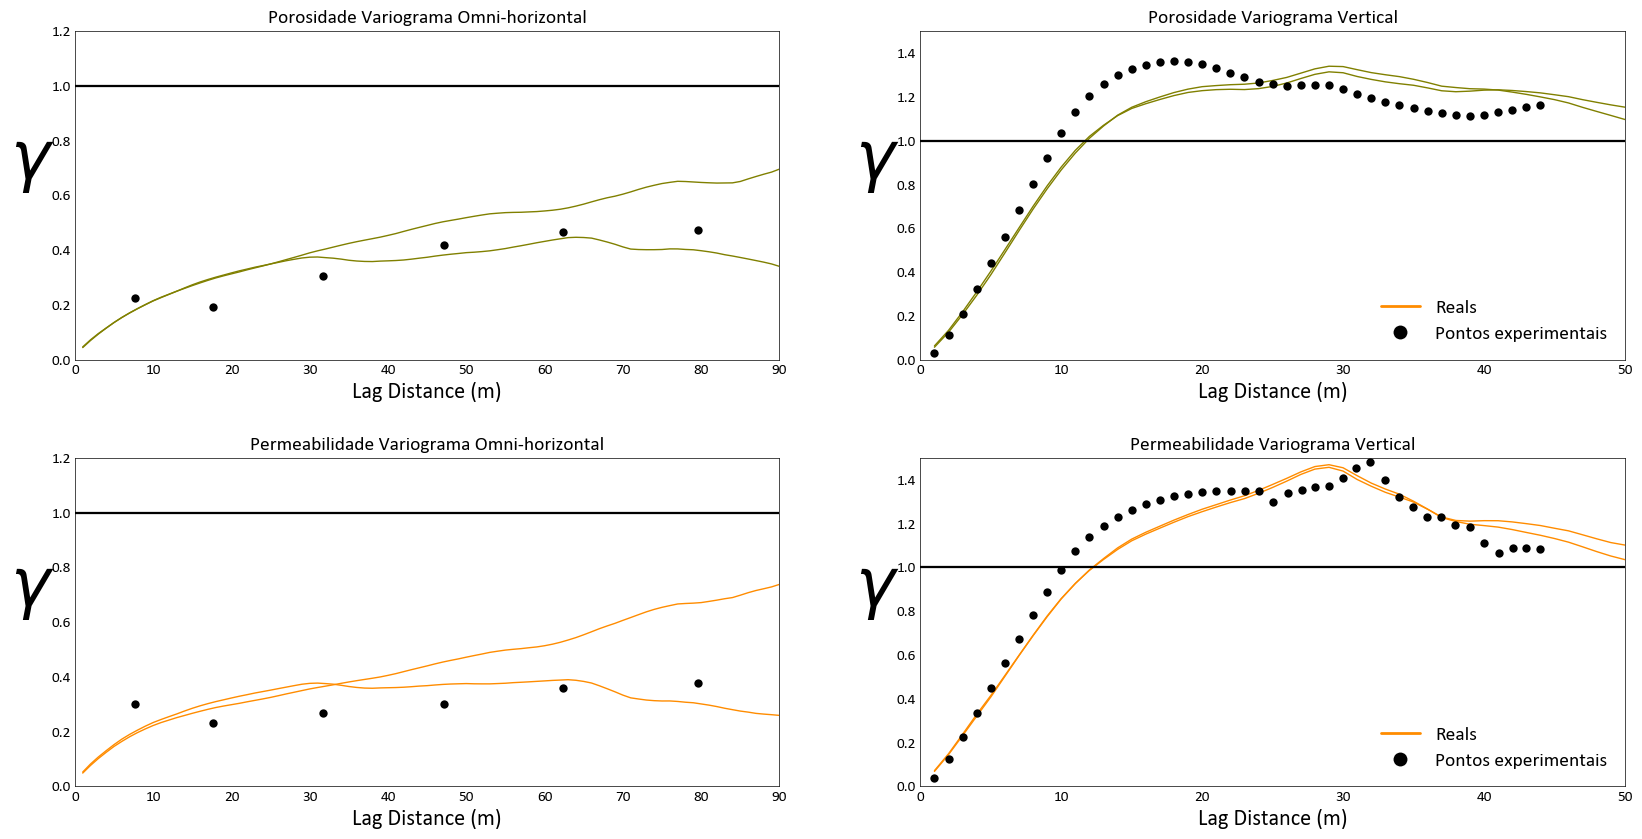

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10)) 

# Primeiro plot para Porosidade index=1
legend_real_poro = mlines.Line2D([], [], color=color_poro, linestyle='-', linewidth=2, label='Reals')
legend_exp_poro = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Pontos experimentais')

for i in range(n_real):
    i_real = i
    outvarsimreals_poro = f'17-Validation/varsim_real{i_real}_poro.out'
    varsim_file_poro = gs.DataFile(outvarsimreals_poro, griddef=grid_3d)
    varsim_df_poro = varsim_file_poro.data

    axs[0, 0] = gs.variogram_plot(data=varsim_df_poro, index=1, experimental=False, label=None, color=color_poro, ylim=[0, 1.2], xlim=[0, 90], ax=axs[0, 0])

exp_varg_poro = gs.DataFile('05-Varcalc/varcalc_Poro.out')
model_line = gs.variogram_plot(data=exp_varg_poro, index=1, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 90], ax=axs[0, 0])
axs[0, 0].set_title('Porosidade Variograma Omni-horizontal', fontsize=14)

# Segundo plot para Porosidade index=2
for i in range(n_real):
    outvarsimreals_poro = f'17-Validation/varsim_real{i}_poro.out'
    varsim_file_poro = gs.DataFile(outvarsimreals_poro, griddef=grid_3d)
    varsim_df_poro = varsim_file_poro.data

    axs[0, 1] = gs.variogram_plot(data=varsim_df_poro, index=2, experimental=False, label=None, color=color_poro, ylim=[0, 1.5], xlim=[0, 50], ax=axs[0, 1])

model_line = gs.variogram_plot(data=exp_varg_poro, index=2, experimental=True, label='Original Model', color='black', ylim=[0, 1.5], xlim=[0, 50], ax=axs[0, 1])
axs[0, 1].set_title('Porosidade Variograma Vertical', fontsize=14)
ax=axs[0, 1].legend(handles=[legend_real, legend_exp], fontsize=14, loc='lower right')

# Primeiro plot para Permeabilidade index=1
legend_real_perm = mlines.Line2D([], [], color=color_perm, linestyle='-', linewidth=2, label='Reals')
legend_exp_perm = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Pontos experimentais')

for i in range(n_real):
    i_real = i
    outvarsimreals_perm = f'17-Validation/varsim_reals_perm_real{i}.out'
    varsim_file_perm = gs.DataFile(outvarsimreals_perm, griddef=grid_3d)
    varsim_df_perm = varsim_file_perm.data

    axs[1, 0] = gs.variogram_plot(data=varsim_df_perm, index=1, experimental=False, label=None, color=color_perm, ylim=[0, 1.2], xlim=[0, 90], ax=axs[1, 0])

exp_varg_perm = gs.DataFile('05-Varcalc/varcalc_Perm.out')
model_line = gs.variogram_plot(data=exp_varg_perm, index=1, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 90], ax=axs[1, 0])
axs[1, 0].set_title('Permeabilidade Variograma Omni-horizontal', fontsize=14)

for i in range(n_real):
    outvarsimreals_perm = f'17-Validation/varsim_reals_perm_real{i}.out'
    varsim_file_perm = gs.DataFile(outvarsimreals_perm, griddef=grid_3d)
    varsim_df_perm = varsim_file_perm.data

    axs[1] = gs.variogram_plot(data=varsim_df_perm, index=2, experimental=False, label=None, color=color_perm, ylim=[0, 1.5], xlim=[0, 50], ax=axs[1, 1])

model_line = gs.variogram_plot(data=exp_varg_perm, index=2, experimental=True, label='Original Model', color='black', ylim=[0, 1.5], xlim=[0, 50], ax=axs[1, 1])
ax=axs[1, 1].set_title('Permeabilidade Variograma Vertical', fontsize=14)
ax=axs[1, 1].legend(handles=[legend_real, legend_exp], fontsize=14, loc='lower right')

plt.subplots_adjust(hspace=0.3)
plt.savefig(f'{path}ppmt_vars_validation')
plt.show()


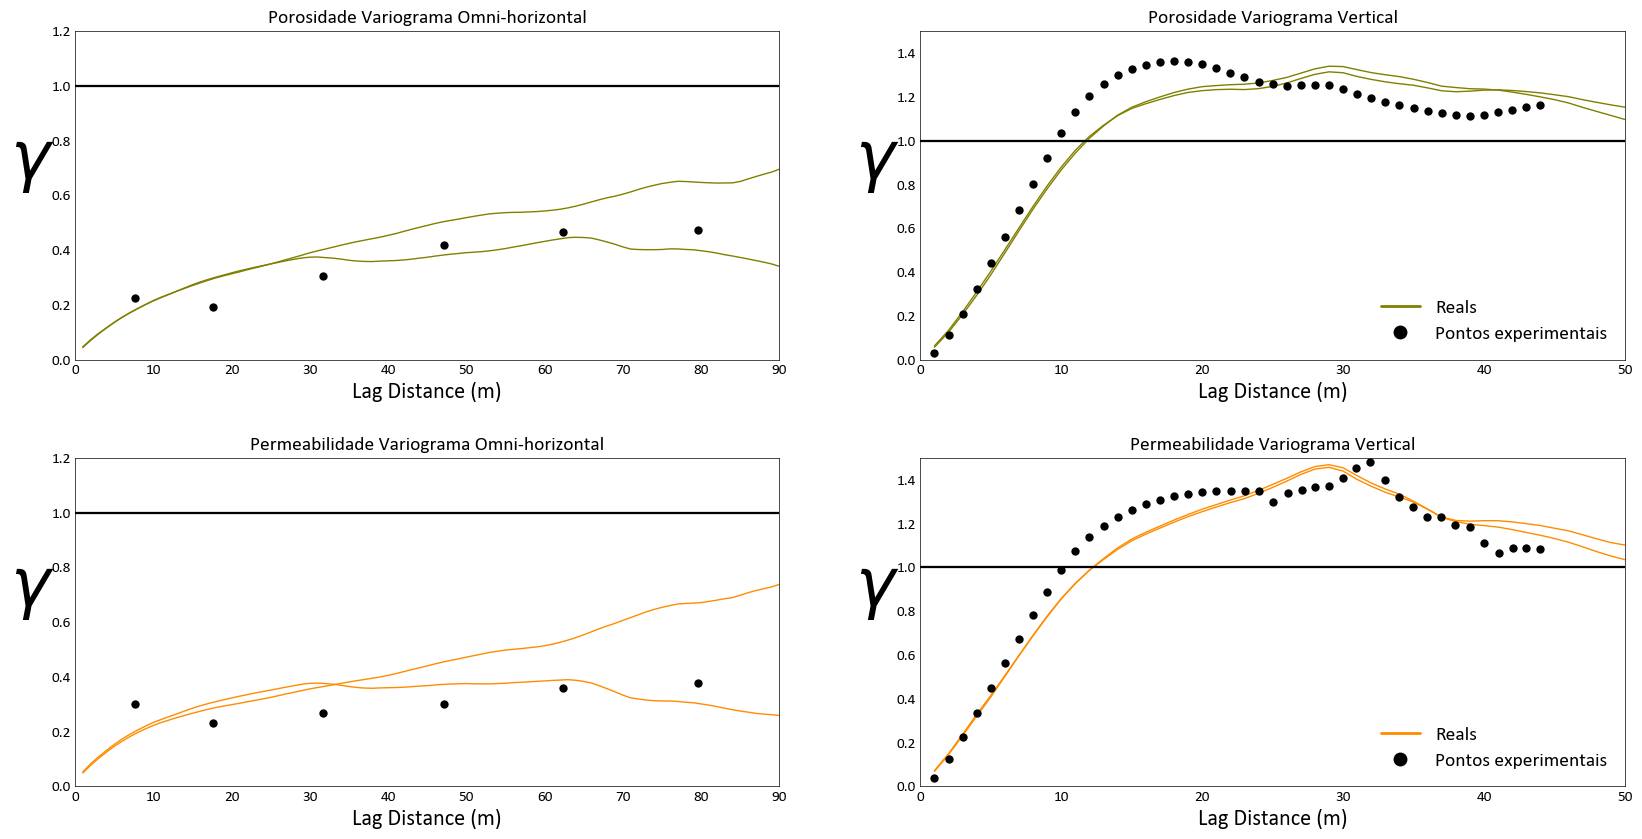

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10)) 

# Primeiro plot para Porosidade index=1
legend_real_poro = mlines.Line2D([], [], color=color_poro, linestyle='-', linewidth=2, label='Reals')
legend_exp_poro = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Pontos experimentais')

for i in range(n_real):
    i_real = i
    outvarsimreals_poro = f'17-Validation/varsim_real{i_real}_poro.out'
    varsim_file_poro = gs.DataFile(outvarsimreals_poro, griddef=grid_3d)
    varsim_df_poro = varsim_file_poro.data

    axs[0, 0] = gs.variogram_plot(data=varsim_df_poro, index=1, experimental=False, label=None, color=color_poro, ylim=[0, 1.2], xlim=[0, 90], ax=axs[0, 0])

exp_varg_poro = gs.DataFile('05-Varcalc/varcalc_Poro.out')
model_line = gs.variogram_plot(data=exp_varg_poro, index=1, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 90], ax=axs[0, 0])
axs[0, 0].set_title('Porosidade Variograma Omni-horizontal', fontsize=14)

# Segundo plot para Porosidade index=2
for i in range(n_real):
    outvarsimreals_poro = f'17-Validation/varsim_real{i}_poro.out'
    varsim_file_poro = gs.DataFile(outvarsimreals_poro, griddef=grid_3d)
    varsim_df_poro = varsim_file_poro.data

    axs[0, 1] = gs.variogram_plot(data=varsim_df_poro, index=2, experimental=False, label=None, color=color_poro, ylim=[0, 1.5], xlim=[0, 50], ax=axs[0, 1])

model_line = gs.variogram_plot(data=exp_varg_poro, index=2, experimental=True, label='Original Model', color='black', ylim=[0, 1.5], xlim=[0, 50], ax=axs[0, 1])
axs[0, 1].set_title('Porosidade Variograma Vertical', fontsize=14)
axs[0, 1].legend(handles=[legend_real_poro, legend_exp_poro], fontsize=14, loc='lower right')

# Primeiro plot para Permeabilidade index=1
legend_real_perm = mlines.Line2D([], [], color=color_perm, linestyle='-', linewidth=2, label='Reals')
legend_exp_perm = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Pontos experimentais')

for i in range(n_real):
    i_real = i
    outvarsimreals_perm = f'17-Validation/varsim_reals_perm_real{i}.out'
    varsim_file_perm = gs.DataFile(outvarsimreals_perm, griddef=grid_3d)
    varsim_df_perm = varsim_file_perm.data

    axs[1, 0] = gs.variogram_plot(data=varsim_df_perm, index=1, experimental=False, label=None, color=color_perm, ylim=[0, 1.2], xlim=[0, 90], ax=axs[1, 0])

exp_varg_perm = gs.DataFile('05-Varcalc/varcalc_Perm.out')
model_line = gs.variogram_plot(data=exp_varg_perm, index=1, experimental=True, label='Original Model', color='black', ylim=[0, 1.2], xlim=[0, 90], ax=axs[1, 0])
axs[1, 0].set_title('Permeabilidade Variograma Omni-horizontal', fontsize=14)

# Segundo plot para Permeabilidade index=2
for i in range(n_real):
    outvarsimreals_perm = f'17-Validation/varsim_reals_perm_real{i}.out'
    varsim_file_perm = gs.DataFile(outvarsimreals_perm, griddef=grid_3d)
    varsim_df_perm = varsim_file_perm.data

    axs[1, 1] = gs.variogram_plot(data=varsim_df_perm, index=2, experimental=False, label=None, color=color_perm, ylim=[0, 1.5], xlim=[0, 50], ax=axs[1, 1])

model_line = gs.variogram_plot(data=exp_varg_perm, index=2, experimental=True, label='Original Model', color='black', ylim=[0, 1.5], xlim=[0, 50], ax=axs[1, 1])
axs[1, 1].set_title('Permeabilidade Variograma Vertical', fontsize=14)
axs[1, 1].legend(handles=[legend_real_perm, legend_exp_perm], fontsize=14, loc='lower right')

plt.subplots_adjust(hspace=0.3)
plt.savefig(f'{path}ppmt_vars_validation')
plt.show()


# Etype, P90, P10, std

In [ ]:
# e_type_poro = np.mean(a=reals_poro_df, axis=1)
# e_type_perm = np.mean(a=reals_perm_df, axis=1)

# fig, axes = plt.subplots(1,2)

# gs.slice_plot(e_type_poro, orient='xz', title=f'{first_real} Porosidade', pointdata=data, pointvar='Poro', pointtol=20, griddef=grid_3d, ax=axes[0])
    
# gs.slice_plot(e_type_perm, orient='xz',title=f'{first_real} Permeabilidade',pointdata=data, pointvar='Perm',pointtol=20, griddef=grid_3d, ax=axes[1])

# plt.subplots_adjust(wspace=0.5)
# plt.show


In [ ]:
# path = '19-etype'

# e_type_perm.to_csv(f'{path}/etype_ppmt-fpca-sgsim_perm.csv')
# e_type_poro.to_csv(f'{path}/etype_ppmt-fpca-sgsim_poro.csv')
